# Event Prediction : prédiction de la bactériémie

## Contexte

Les prédicteurs des bactériémies restent mal caractérisés.
L'objectif du défi 1 est de **développer et valider un modèle de prédiction de la survenue d'une bactériémie** chez les patients.

## Données

- **Fichier** : `bacteriemie.csv.gz`
- **Taille** : 11 753 observations provenant de différents patients présentant une suspicion clinique de bactériémie, pour lesquels une analyse de culture de sang a été réalisée à l'Hôpital général de Vienne (Autriche), entre janvier 2006 et décembre 2010.
- **Variables** : le résultat de l'analyse de culture de sang pour la bactériémie et les valeurs de **51 prédicteurs potentiels**.
- **Confidentialité** : afin de protéger la confidentialité des données, cette version a été légèrement modifiée par rapport à l'originale ; la version modifiée a été approuvée par l'Université médicale de Vienne pour un usage public (DC 2019-0054).
- **Dictionnaire des variables** : fichier `cahierVariables.csv`

## Travail demandé

* Développer un modèle permettant de prédire la survenue d'une bactériémie pour un patient.
* Le rendu est un code qui peut fonctionner sur un fichier de même structure que le fichier de données initial et qui retourne la présence (1) ou l'absence (0) de bactériémie pour chaque sujet.

Le script sera utilisé pour prédire un jeu de test qui n'est pas encore mis à disposition. Les performances de l'algorithme seront évaluées. Un bonus sera attribué au groupe qui obtiendra la meilleure performance (**F1 score**, puis **précision** en cas d'égalité) sur le jeu de test.

Les groupes sont définis dans le fichier `GroupesIDS2026.xlsx`.

## Échéances

| Date | Rendu |
|---|---|
| **05/10/2026 à 18h** | [Retour des scripts](https://moodle.unistra.fr/mod/assign/view.php?id=459529) sur Moodle (remise de devoirs : fichier `.r`, `.py` ou `.ipynb`) |
| **07/10/2026 à 18h** | Fichier de prédiction du jeu de test au format `.csv` |
| **08/10/2026, 14h-16h** | Présentations orales et dévoilement du classement |

**Format du fichier de prédiction** : le nom comporte le groupe et un nom (par exemple `Groupe2_godet.csv`). Le fichier contient 2 colonnes :
- `ID` : identifiant issu du fichier de test
- `pred` : uniquement des 0 (absence de bactériémie) ou des 1 (présence)

## Mots-clés

**FR** : Santé, analyse exploratoire des données, nettoyage des données, classification binaire, réduction de la dimensionnalité, sous- et sur-échantillonnage, données déséquilibrées, super-learner, apprentissage profond.

**EN** : Health, Exploratory Data Analysis, Data Cleaning, Categorical Data, Binary classification, Dimensionality reduction, under-/over-sampling, unbalanced weighting, super-learner, deep learning

### Pourquoi ce problème

La bactériémie, c'est-à-dire la présence de bactéries dans le sang, est fréquente et grave : sa mortalité est élevée. Le diagnostic repose sur l'hémoculture, un examen long et peu rentable, car la grande majorité des prélèvements revient négative. Dans nos données, 8 % seulement sont positifs.

L'étude d'origine a donc construit un modèle de risque à partir d'analyses de routine, faciles à standardiser d'un hôpital à l'autre. Son but était d'aider à la décision en repérant automatiquement les patients à très faible risque, chez qui l'hémoculture peut être évitée.

### Notre objectif

Prédire, pour chaque patient, la présence (1) ou l'absence (0) de bactériémie à partir des seules analyses de routine, puis livrer un script qui applique ce modèle à un fichier de même structure et renvoie deux colonnes, `ID` et `pred`.

Le classement se fait au **F1 score**, puis à la précision en cas d'égalité. Il faut donc détecter le maximum de bactériémies sans multiplier les fausses alertes, et c'est le réglage du seuil de décision qui arbitre entre les deux.

**Une différence avec l'article** : il cherchait avant tout à *écarter* les patients sans bactériémie, donc à ne manquer aucun malade, quitte à générer des alertes inutiles. Le F1 pénalise ces alertes. Notre seuil optimal ne sera donc pas le sien.

*Source des données et du contexte : Ratzinger F. et al., « A Risk Prediction Model for Screening Bacteremic Patients: A Cross Sectional Study », PLoS ONE 9(9), e106765, 2014.*

In [2]:
import polars as pl
import seaborn as sns 
import matplotlib.pyplot as plt
import math 
import missingno as msno

In [3]:
pl.Config.set_tbl_cols(-1) # afficher toute les colonnes 
pl.Config.set_tbl_rows(-1) # afficher toute les lignes

polars.config.Config

In [4]:
# Cahier des variables : utile pour titrer les graphiques avec le nom complet et l'unité
cahier = pl.read_csv("../doc/cahierVariables.csv").select(
    "VariableNr", "Variable", "Label", "Scale.of.measurement", "Units", "Remark"
)

# Unités par variable, en corrigeant les erreurs du cahier (voir « Réserves » plus haut)
unites = dict(zip(cahier["Variable"], cahier["Units"])) | {
    "MCV": "fl", "MCH": "pg", "HGB": "g/dl", "GGT": "U/L", "LYMR": "%", "AGE": "ans",
}

# Dictionnaire code -> "Nom complet (unité)", ex. labels["CRP"] -> "C-reactive protein (mg/dl)"
labels = {
    code: f"{nom} ({unites[code]})" if unites[code] else nom
    for code, nom in zip(cahier["Variable"], cahier["Label"])
}

cahier.sort("VariableNr")

VariableNr,Variable,Label,Scale.of.measurement,Units,Remark
i64,str,str,str,str,str
1,"""ID""","""Patient Identification""","""nominal""","""1-14691""",""""""
2,"""SEX""","""Patient sex""","""nominal""","""1=male, 2=female""",""""""
3,"""AGE""","""Patient Age""","""continuous""","""years""","""Alter=German age"""
4,"""MCV""","""Mean corpuscular volume""","""continuous""","""pg""",""""""
5,"""HGB""","""Haemoglobin""","""continuous""","""G/L""",""""""
6,"""HCT""","""Haematocrit""","""continuous""","""%""",""""""
7,"""PLT""","""Blood platelets""","""continuous""","""G/L""",""""""
8,"""MCH""","""Mean corpuscular hemoglobin""","""continuous""","""fl""",""""""
9,"""MCHC""","""Mean corpuscular hemoglobin co…","""continuous""","""g/dl""",""""""


In [5]:
df = pl.read_csv("../data/bacteriemie.csv.gz", null_values="NA")
df.head()

ID,SEX,AGE,MCV,HGB,HCT,PLT,MCH,MCHC,RDW,MPV,LYM,MONO,EOS,BASO,NT,APTT,FIB,SODIUM,POTASS,CA,PHOS,MG,CREA,BUN,HS,GBIL,TP,ALB,AMY,PAMY,LIP,CHE,AP,ASAT,ALAT,GGT,LDH,CK,GLU,TRIG,CHOL,CRP,BASOR,EOSR,LYMR,MONOR,NEU,NEUR,PDW,RBC,WBC,BloodCulture
i64,i64,i64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
1,2,62,99.3,11.5,35.9,307,31.5,31.8,19.5,10.8,0.4,1.7,0.0,0.1,86,28.8,578,137,3.88,2.29,1.2,0.66,0.65,5.7,5.3,0.59,67.0,36.7,30,16,10,5.12,85,22,14,48,284,23,107,105,175,3.94,0.413223,0.0,1.652893,7.024793,22.0,90.909091,10.6,3.7,24.1,"""no"""
3,1,72,85.1,10.3,34.7,182,26.0,30.6,15.0,9.7,0.4,0.2,0.1,0.0,90,29.8,null,141,null,2.21,0.58,null,0.76,19.9,null,0.48,65.3,37.4,null,null,null,5.61,80,28,25,61,null,36,84,null,null,1.42,0.0,0.826446,3.305785,1.652893,11.4,94.214876,11.4,3.9,12.17,"""no"""
5,1,46,96.3,7.4,22.8,64,31.2,32.4,19.7,11.1,1.5,1.2,0.1,0.1,58,36.3,313,147,4.61,1.92,1.51,1.03,1.25,50.6,null,8.42,40.5,22.1,146,null,89,2.52,119,124,135,134,696,40,107,null,null,12.09,0.568182,0.568182,8.522727,6.818182,14.7,83.522727,14.1,2.5,17.45,"""no"""
9,2,38,85.1,13.7,38.7,183,30.2,35.3,12.6,10.0,0.8,0.4,0.0,0.0,95,33.1,490,137,null,2.34,0.97,0.74,0.65,8.5,3.0,0.42,78.4,43.8,84,50,50,6.91,108,35,22,72,null,79,93,152,167,11.17,0.0,0.0,8.333333,4.166667,8.4,87.5,12.2,4.4,9.86,"""no"""
10,1,68,104.5,15.7,46.9,144,34.8,33.5,13.9,10.9,2.2,0.9,0.1,0.0,61,41.8,400,141,4.41,2.08,0.99,0.56,0.82,15.3,5.5,2.4,57.5,30.1,95,57,25,6.79,68,32,11,68,263,75,89,85,144,5.89,0.0,1.0,22.0,9.0,6.8,68.0,12.9,4.3,9.94,"""no"""


### Doublons ?? 

In [6]:
# Lignes strictement identiques sur les 53 colonnes
dup_ligne=df.is_duplicated().sum()
print("Nombre de ligne strictement identiques sur les 53 colonnes :",dup_ligne)

Nombre de ligne strictement identiques sur les 53 colonnes : 0


In [7]:
# # Identifiants en double : ID doit être unique, c'est la clé du fichier
print("ID dupliqués :",df.select(pl.col("ID").is_duplicated().sum()))

ID dupliqués : shape: (1, 1)
┌─────┐
│ ID  │
│ --- │
│ u32 │
╞═════╡
│ 0   │
└─────┘


In [8]:
# Deux lignes peuvent avoir des ID distincts mais des valeurs biologiques toutes identiques
print("doublons hors ID :", df.drop("ID").is_duplicated().sum())

doublons hors ID : 0


In [9]:
df.schema

Schema([('ID', Int64),
        ('SEX', Int64),
        ('AGE', Int64),
        ('MCV', Float64),
        ('HGB', Float64),
        ('HCT', Float64),
        ('PLT', Int64),
        ('MCH', Float64),
        ('MCHC', Float64),
        ('RDW', Float64),
        ('MPV', Float64),
        ('LYM', Float64),
        ('MONO', Float64),
        ('EOS', Float64),
        ('BASO', Float64),
        ('NT', Int64),
        ('APTT', Float64),
        ('FIB', Int64),
        ('SODIUM', Int64),
        ('POTASS', Float64),
        ('CA', Float64),
        ('PHOS', Float64),
        ('MG', Float64),
        ('CREA', Float64),
        ('BUN', Float64),
        ('HS', Float64),
        ('GBIL', Float64),
        ('TP', Float64),
        ('ALB', Float64),
        ('AMY', Int64),
        ('PAMY', Int64),
        ('LIP', Int64),
        ('CHE', Float64),
        ('AP', Int64),
        ('ASAT', Int64),
        ('ALAT', Int64),
        ('GGT', Int64),
        ('LDH', Int64),
        ('CK', Int64),
        ('

In [10]:
df.describe()

statistic,ID,SEX,AGE,MCV,HGB,HCT,PLT,MCH,MCHC,RDW,MPV,LYM,MONO,EOS,BASO,NT,APTT,FIB,SODIUM,POTASS,CA,PHOS,MG,CREA,BUN,HS,GBIL,TP,ALB,AMY,PAMY,LIP,CHE,AP,ASAT,ALAT,GGT,LDH,CK,GLU,TRIG,CHOL,CRP,BASOR,EOSR,LYMR,MONOR,NEU,NEUR,PDW,RBC,WBC,BloodCulture
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str
"""count""",11753.0,11753.0,11753.0,11716.0,11716.0,11716.0,11715.0,11716.0,11716.0,11702.0,11188.0,11541.0,11559.0,11639.0,11632.0,9774.0,9701.0,9688.0,10711.0,10147.0,10724.0,10756.0,10240.0,11629.0,11617.0,9285.0,10602.0,10471.0,10410.0,8651.0,6106.0,8828.0,9779.0,10628.0,10833.0,10965.0,10743.0,10395.0,10092.0,8392.0,7700.0,7714.0,11631.0,11161.0,11161.0,11161.0,11161.0,11165.0,11161.0,10864.0,11378.0,11376.0,"""11753"""
"""null_count""",0.0,0.0,0.0,37.0,37.0,37.0,38.0,37.0,37.0,51.0,565.0,212.0,194.0,114.0,121.0,1979.0,2052.0,2065.0,1042.0,1606.0,1029.0,997.0,1513.0,124.0,136.0,2468.0,1151.0,1282.0,1343.0,3102.0,5647.0,2925.0,1974.0,1125.0,920.0,788.0,1010.0,1358.0,1661.0,3361.0,4053.0,4039.0,122.0,592.0,592.0,592.0,592.0,588.0,592.0,889.0,375.0,377.0,"""0"""
"""mean""",29463.153408,1.418276,56.19629,88.318547,11.554908,34.443394,220.271362,29.568163,33.470237,14.99618,10.375313,1.3926,0.855818,0.114632,0.016919,83.117148,40.173869,550.198596,137.20605,4.003089,2.213206,1.048325,0.814354,1.334635,22.73259,5.411125,1.405543,64.801031,33.357618,94.414519,42.853914,66.864975,4.773301,118.645559,85.070341,65.890378,114.595923,330.358826,394.709076,126.361058,141.676364,150.036038,11.027459,0.144129,1.294291,14.586089,8.785591,8.376534,75.1899,12.281858,3.933732,11.254335,null
"""std""",18176.313099,0.493297,18.152923,6.484213,2.252077,6.533899,122.808831,2.536243,1.405105,2.289123,1.005771,8.302584,0.663538,0.275845,0.084297,27.165392,11.094636,207.554111,4.774233,0.648146,0.203588,0.396064,0.150559,1.191337,18.199672,2.466011,2.754676,11.431761,7.434086,896.536848,497.273081,667.776574,2.09956,132.384119,379.64402,285.420837,206.864542,468.038777,2394.391634,56.273605,122.289067,55.41446,9.601233,0.588816,2.363407,12.790056,5.772997,5.622108,15.553618,2.181033,0.775366,13.625156,null
"""min""",1.0,1.0,16.0,52.6,3.0,0.0,0.0,14.9,23.7,10.6,7.3,0.0,0.0,0.0,0.0,4.0,21.4,60.0,106.0,1.92,1.15,0.3,0.2,0.26,2.5,1.3,0.12,29.9,10.0,8.0,1.0,0.0,0.98,11.0,5.0,0.0,3.0,39.0,8.0,19.0,14.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.6,1.0,0.0,"""no"""
"""25%""",13716.0,1.0,43.0,84.7,9.8,29.8,140.0,28.3,32.6,13.4,9.7,0.6,0.5,0.0,0.0,67.0,34.2,399.0,135.0,3.67,2.09,0.81,0.73,0.82,11.7,3.7,0.53,56.8,27.8,33.0,14.0,13.0,3.12,62.0,22.0,16.0,25.0,187.0,41.0,96.0,83.0,113.0,2.99,0.0,0.0,6.741573,5.617978,4.6,69.444444,10.8,3.4,6.65,null
"""50%""",28822.0,1.0,58.0,88.2,11.4,34.3,204.0,29.7,33.5,14.5,10.3,1.0,0.8,0.1,0.0,83.0,37.8,532.0,137.0,3.95,2.22,0.99,0.81,1.0,16.6,5.0,0.76,65.7,33.5,50.0,22.0,23.0,4.59,84.0,31.0,26.0,49.0,239.0,81.0,113.0,115.0,144.0,8.69,0.0,0.568182,11.267606,8.0,7.3,78.472222,12.0,3.9,9.6,null
"""75%""",44789.0,2.0,70.0,92.0,13.2,39.1,277.0,30.9,34.4,16.0,11.0,1.5,1.1,0.1,0.0,101.0,42.8,675.0,140.0,4.29,2.34,1.21,0.89,1.34,27.1,6.6,1.23,73.3,39.0,76.0,36.0,40.0,6.21,123.0,57.0,48.0,118.0,332.0,184.0,138.0,165.0,182.0,16.71,0.0,1.785714,18.181818,10.869565,10.9,85.344828,13.4,4.5,13.55,null
"""max""",62454.0,2.0,101.0,128.7,21.0,66.6,1639.0,47.4,43.5,31.8,15.0,578.1,20.4,15.8,6.5,152.0,176.1,1593.0,170.0,36.62,4.4,6.22,2.22,20.75,184.8,22.7,51.77,120.9,55.7,56146.0,38369.0,45991.0,13.89,2995.0,12079.0,12329.0,5171.0,13906.0,98801.0,1403.0,5440.0,1104.0,76.32,23.655914,73.488372,100.0,100.0,83.8,100.0,25.3,7.7,604.47,"""yes"""


In [11]:
# Nombre et pourcentage de valeurs manquantes par variable
manquants = (
    df.null_count()
    # transpose la retourne en 53 lignes de 2 colonnes, plus lisible.
    .transpose(include_header=True, header_name="variable", column_names=["n_manquants"])
    .with_columns((pl.col("n_manquants") / df.height * 100).round(2).alias("pct_manquants"))
    .sort("n_manquants", descending=True)
)

manquants


variable,n_manquants,pct_manquants
str,u32,f64
"""PAMY""",5647,48.05
"""TRIG""",4053,34.48
"""CHOL""",4039,34.37
"""GLU""",3361,28.6
"""AMY""",3102,26.39
"""LIP""",2925,24.89
"""HS""",2468,21.0
"""FIB""",2065,17.57
"""APTT""",2052,17.46


In [12]:
manquants.filter(pl.col("pct_manquants") > 20)

variable,n_manquants,pct_manquants
str,u32,f64
"""PAMY""",5647,48.05
"""TRIG""",4053,34.48
"""CHOL""",4039,34.37
"""GLU""",3361,28.6
"""AMY""",3102,26.39
"""LIP""",2925,24.89
"""HS""",2468,21.0


In [13]:
# Le pourcentage par colonne trompe 
# On mesure l ampleur réel 
print("lignes complètes :", df.drop_nulls().height, "sur", df.height)

# Nombre de valeurs manquantes par patient
df.select(pl.sum_horizontal(pl.all().is_null()).alias("nb_manquants"))["nb_manquants"].describe()


# 3 197 patients complets sur 11 753, soit 27 %
# 8 556 patients incomplet (73%)
# un quart des patients (25% , premier quartile) n a aucun trou
# la moitier des patient a 3 manquants ou moins 
# et trois quarts en ont 7 ou moins.
# Un patient a 33 manquants sur 52 variables (bilan minimal demander)
# La moyenne depasse la mediane (asymetrique)= une minorité de patient tire moyene vers le haut 

lignes complètes : 3197 sur 11753


statistic,value
str,f64
"""count""",11753.0
"""null_count""",0.0
"""mean""",4.895856
"""std""",5.652268
"""min""",0.0
"""25%""",0.0
"""50%""",3.0
"""75%""",7.0
"""max""",33.0


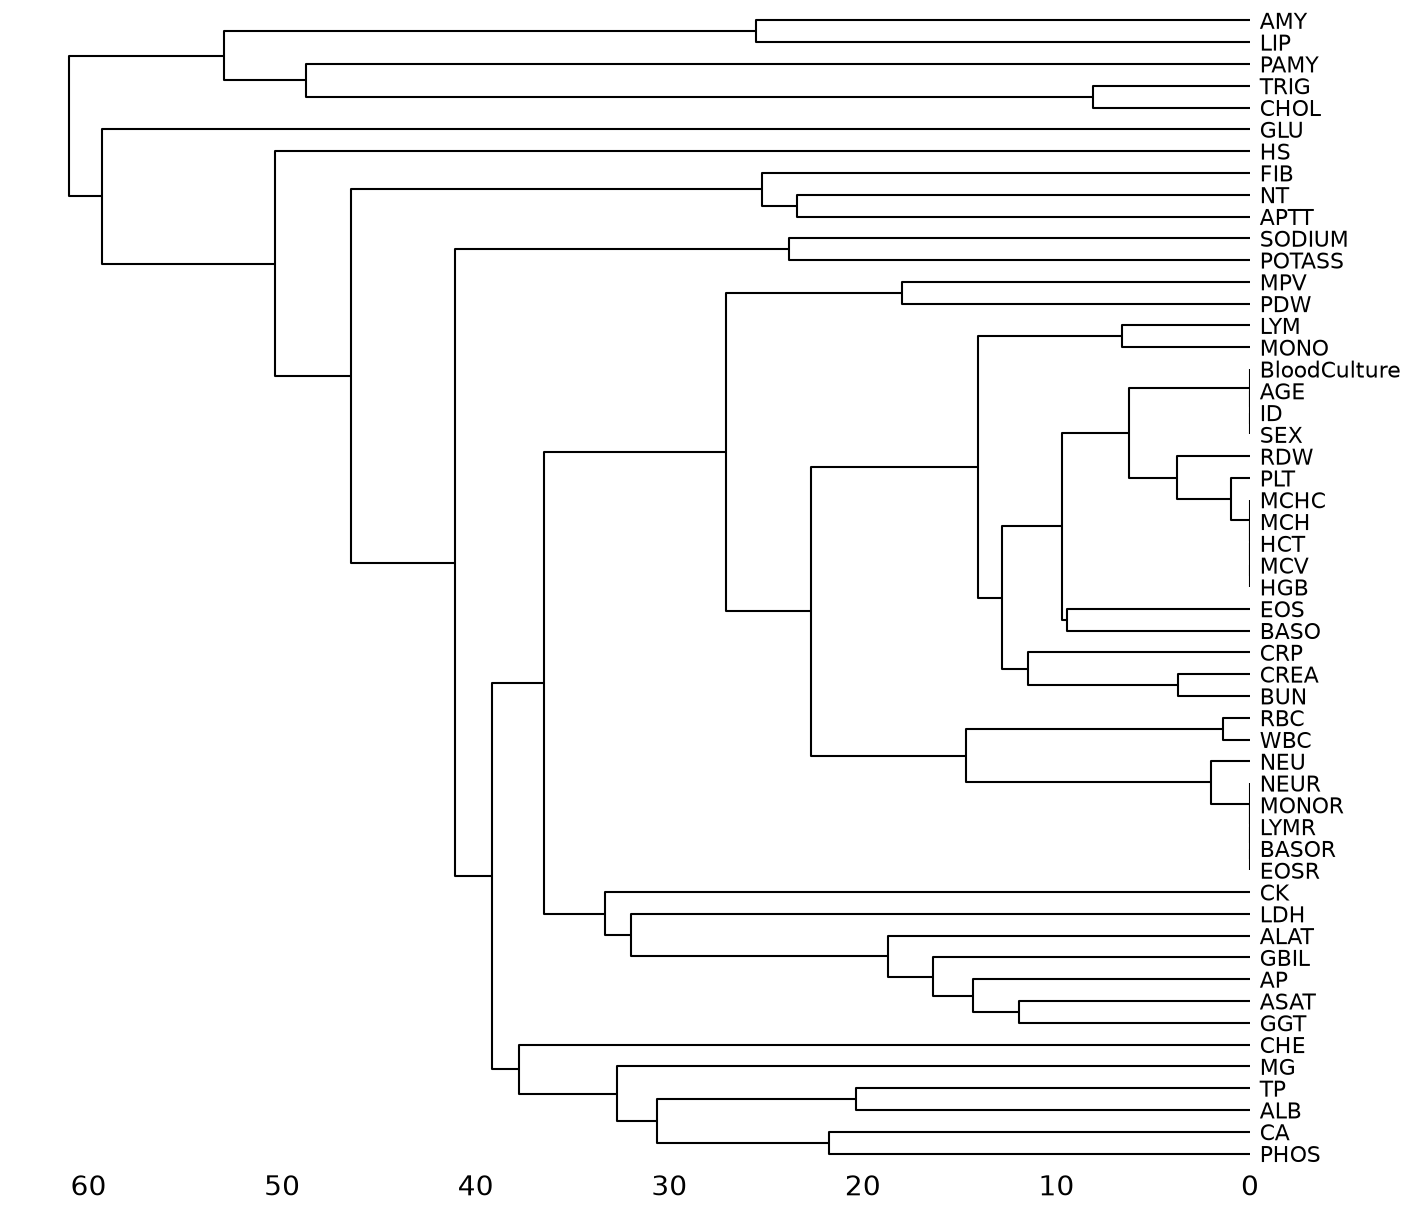

In [14]:
df_pd = df.to_pandas()

msno.dendrogram(df_pd, figsize=(16, 15))
plt.show()

Comment lire le dendogramme ? 

Sur le dendogramme, les noms sont à droite et la distance augmente vers la gauche 

La seule chose à regarder : à quelle hauteur deux traits se rejoignent.

- Ils se rejoignent tout près du bord des noms → elles se ressemblent beaucoup. Quand l'une manque, l'autre manque aussi.
- Ils se rejoignent loin, vers le bout opposé → elles n'ont rien à voir.


### Groupes identifiés par le dendrogramme des manquants

Le dendrogramme de `missingno` regroupe les variables selon leur **profil de présence ou d'absence**, et non selon leurs valeurs.

Les groupes ci-dessous sont obtenus par **lecture du dendrogramme**, en repérant les branches qui fusionnent tôt, puis en nommant chaque groupe selon le panel d'analyses qu'il représente. Ils ne proviennent pas d'une coupe automatique de l'arbre.

| Groupe | Variables | Lecture |
|---|---|---|
| Toujours présentes | `SEX`, `AGE`, `BloodCulture` | Aucun manquant : administratif et cible |
| Hémogramme de base | `HGB`, `HCT`, `MCV`, `MCH`, `MCHC`, `RDW`, `PLT`, `LYM`, `MONO`, `BASO`, `EOS` | Réalisé chez presque tous les patients (moins de 1 % de manquants) |
| Biochimie systématique | `CRP`, `CREA`, `BUN` | Prescrite d'emblée devant une suspicion d'infection |
| Formule leucocytaire détaillée | `NEU`, `NEUR`, `LYMR`, `MONOR`, `BASOR`, `EOSR`, `RBC`, `WBC` | Étape supplémentaire de l'hémogramme, pas toujours faite |
| Indices plaquettaires | `MPV`, `PDW` | Sous-produit de la numération plaquettaire |
| Coagulation | `NT`, `APTT`, `FIB` | `NT` et `APTT` fusionnent très tôt, `FIB` est prescrit plus rarement |
| Ionogramme et minéraux | `SODIUM`, `POTASS`, `MG`, `CA`, `PHOS` | Bilan ionique, prescrit comme un tout |
| Foie et protéines | `GGT`, `ASAT`, `ALAT`, `AP`, `GBIL`, `CHE`, `ALB`, `TP` | Bilan hépatique complet |
| Muscle et lyse cellulaire | `CK`, `LDH` | Prescrit dans des situations précises |
| Pancréas | `AMY`, `LIP`, `PAMY` | Panel le plus souvent absent : `PAMY` manque chez 48 % des patients |
| Lipides et glucose | `TRIG`, `CHOL`, `GLU` | Bilan métabolique, indépendant du reste : il ne rejoint les autres variables qu'à la toute fin de l'arbre |

**Ce que ces groupes impliquent**

Les valeurs ne manquent pas au hasard : elles manquent par panel, c'est-à-dire selon ce que le médecin a jugé utile de prescrire. Le mécanisme n'est donc pas MCAR.


| Constat | Décision |
|---|---|
| 27 % de lignes complètes seulement | Aucune suppression de lignes |
| Les manquants se regroupent par panel d'analyses | Mécanisme non MCAR |
| Un panel absent traduit une décision médicale | MAR probable, MNAR non exclu |
| `PAMY` manque chez 48 % des patients | Variable conservée avec son indicateur |

**Stratégie retenue** : comparer trois variantes par validation croisée sur le F1.

- **A** : LightGBM ou XGBoost, sans imputation (gere `null` nativement) ;
- **B** : médiane et indicateurs de manquant avec régression logistique et Random Forest ;
- **C** : `IterativeImputer` et indicateurs.

Dans les trois cas, l'imputation est calculée sur l'entraînement seulement, à l'intérieur d'un `Pipeline` scikit-learn, pour éviter toute fuite de données vers le jeu de test.


In [15]:
df=(
    df.drop("ID")
    .with_columns(pl.col("BloodCulture")
    .replace_strict({"no":0,"yes":1})
    .cast(pl.Int8))
)

**Situer les valeurs par rapport à la norme**

La fonction ci-dessous sert dans tous les groupes : pour chaque variable, elle donne la part de patients sous la norme, dans la norme et au-dessus. Les bornes retenues sont des ordres de grandeur adultes, sans distinction de sexe.

In [16]:
def part_hors_norme(df, bornes):
    """Part des patients sous, dans et au-dessus de la norme, variable par variable."""
    lignes = []
    for col, (bas, haut) in bornes.items():
        s = df[col].drop_nulls()
        lignes.append({
            "variable": col,
            "norme": f"{bas} - {haut}",
            "sous_%": round((s < bas).mean() * 100, 1),
            "dans_%": round(((s >= bas) & (s <= haut)).mean() * 100, 1),
            "au_dessus_%": round((s > haut).mean() * 100, 1),
        })
    return pl.DataFrame(lignes)


In [17]:
def resume_manquants(df):
    """Nombre et part de valeurs manquantes, variable par variable, du groupe passe en argument."""
    return (
        df.null_count()
        .transpose(include_header=True, header_name="variable", column_names=["n_manquants"])
        .with_columns(pct_manquants=(pl.col("n_manquants") / df.height * 100).round(2))
        .sort("n_manquants", descending=True)
    )


##### Groupe 1 : variables toujours présentes

`SEX`, `AGE` et `BloodCulture` n'ont aucune valeur manquante. Ce sont les deux variables administratives et la cible.

In [18]:
demographie = ["SEX", "AGE", "BloodCulture"]
df_demo = df.select(demographie)
df_demo.head()

SEX,AGE,BloodCulture
i64,i64,i8
2,62,0
1,72,0
1,46,0
2,38,0
1,68,0


In [19]:
resume_manquants(df_demo)


variable,n_manquants,pct_manquants
str,u32,f64
"""SEX""",0,0.0
"""AGE""",0,0.0
"""BloodCulture""",0,0.0


In [20]:
df_demo.describe()


statistic,SEX,AGE,BloodCulture
str,f64,f64,f64
"""count""",11753.0,11753.0,11753.0
"""null_count""",0.0,0.0,0.0
"""mean""",1.418276,56.19629,0.08032
"""std""",0.493297,18.152923,0.271799
"""min""",1.0,16.0,0.0
"""25%""",1.0,43.0,0.0
"""50%""",1.0,58.0,0.0
"""75%""",2.0,70.0,0.0
"""max""",2.0,101.0,1.0


In [21]:
# Effectif et part de chaque classe de la cible
df_demo.group_by("BloodCulture").agg(n=pl.len()).with_columns(
    part=(pl.col("n") / df_demo.height * 100).round(2)
).sort("BloodCulture")


BloodCulture,n,part
i8,u32,f64
0,10809,91.97
1,944,8.03


In [22]:
# Taux de bactériémie par sexe, puis par tranche d'âge
print(df_demo.group_by("SEX")
    .agg(n=pl.len(), taux=(pl.col("BloodCulture")
    .mean() * 100).round(2)).sort("SEX"))

print(
    df_demo.with_columns(tranche=(pl.col("AGE") // 20 * 20))
    .group_by("tranche").agg(n=pl.len(), taux=(pl.col("BloodCulture").mean() * 100).round(2))
    .sort("tranche")
)


shape: (2, 3)
┌─────┬──────┬──────┐
│ SEX ┆ n    ┆ taux │
│ --- ┆ ---  ┆ ---  │
│ i64 ┆ u32  ┆ f64  │
╞═════╪══════╪══════╡
│ 1   ┆ 6837 ┆ 8.16 │
│ 2   ┆ 4916 ┆ 7.85 │
└─────┴──────┴──────┘
shape: (6, 3)
┌─────────┬──────┬───────┐
│ tranche ┆ n    ┆ taux  │
│ ---     ┆ ---  ┆ ---   │
│ i64     ┆ u32  ┆ f64   │
╞═════════╪══════╪═══════╡
│ 0       ┆ 139  ┆ 2.88  │
│ 20      ┆ 2338 ┆ 3.68  │
│ 40      ┆ 3626 ┆ 6.92  │
│ 60      ┆ 4489 ┆ 10.43 │
│ 80      ┆ 1160 ┆ 11.64 │
│ 100     ┆ 1    ┆ 0.0   │
└─────────┴──────┴───────┘


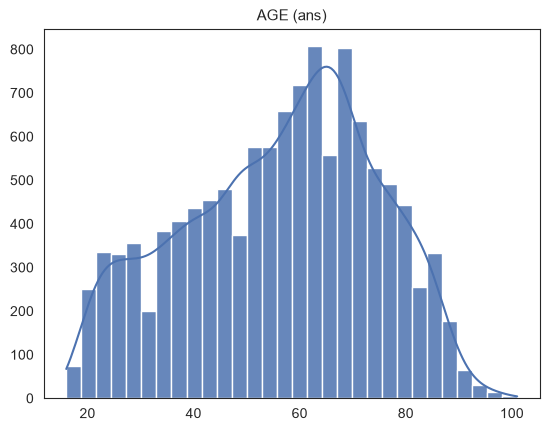

In [23]:
sns.set_style("white")
sns.histplot(df_demo["AGE"], bins=30, kde=True, color="#4C72B0", alpha=0.85)
plt.title("AGE (ans)", fontsize=11)
plt.xlabel("")
plt.ylabel("")
plt.show()


In [24]:
forme = pl.DataFrame({
    "variable": ["AGE"],
    "asymetrie": [df_demo["AGE"].skew()],
    "kurtosis": [df_demo["AGE"].kurtosis()],
})

forme


variable,asymetrie,kurtosis
str,f64,f64
"""AGE""",-0.242594,-0.793205


**Valeurs usuelles et signification**

| Variable | Valeurs | Lecture |
|---|---|---|
| `SEX` | 1 = homme, 2 = femme | Variable catégorielle, à ne pas traiter comme un nombre |
| `AGE` | 16 à 101 ans | Facteur de risque d'infection grave |
| `BloodCulture` | 0 = pas de bactériémie, 1 = bactériémie | La cible à prédire |

**Constats sur les variables toujours présentes**

- **La cible est très déséquilibrée** : 8,03 % de bactériémies contre 91,97 % de cultures négatives.

- **Population plutôt âgée** : âge médian de 58 ans, la moitié des patients entre 43 et 70 ans, aucun mineur.

- **Le risque augmente nettement avec l'âge** : 3,7 % de bactériémies chez les 20-39 ans, 6,9 % chez les 40-59 ans, 10,4 % chez les 60-79 ans et 11,6 % au-delà de 80 ans. L'âge est donc un prédicteur utile.

- **Le sexe ne distingue rien** : 8,16 % chez les hommes contre 7,85 % chez les femmes.

- **La distribution de l'âge est presque symétrique et aplatie** (asymétrie −0,24, kurtosis −0,79) : les patients se répartissent largement sur toute la plage adulte.

##### Groupe 2 : hémogramme de base

Onze variables réalisées chez presque tous les patients, avec moins de 2 % de manquants : la lignée rouge, les plaquettes et les leucocytes en valeur absolue.

Note : `RBC` et `WBC` appartiennent cliniquement à cette famille, mais le dendrogramme les place dans le groupe 4, car elles manquent chez 3,2 % des patients et non 0,3 %.

In [25]:
hemogramme = ["HGB", "HCT", "MCV", "MCH", "MCHC", "RDW", "PLT", "LYM", "MONO", "BASO", "EOS"]
df_hemo = df.select(hemogramme)
df_hemo.head()


HGB,HCT,MCV,MCH,MCHC,RDW,PLT,LYM,MONO,BASO,EOS
f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64
11.5,35.9,99.3,31.5,31.8,19.5,307,0.4,1.7,0.1,0.0
10.3,34.7,85.1,26.0,30.6,15.0,182,0.4,0.2,0.0,0.1
7.4,22.8,96.3,31.2,32.4,19.7,64,1.5,1.2,0.1,0.1
13.7,38.7,85.1,30.2,35.3,12.6,183,0.8,0.4,0.0,0.0
15.7,46.9,104.5,34.8,33.5,13.9,144,2.2,0.9,0.0,0.1


In [26]:
resume_manquants(df_hemo)


variable,n_manquants,pct_manquants
str,u32,f64
"""LYM""",212,1.8
"""MONO""",194,1.65
"""BASO""",121,1.03
"""EOS""",114,0.97
"""RDW""",51,0.43
"""PLT""",38,0.32
"""HGB""",37,0.31
"""HCT""",37,0.31
"""MCV""",37,0.31


In [27]:
df_hemo.describe()

statistic,HGB,HCT,MCV,MCH,MCHC,RDW,PLT,LYM,MONO,BASO,EOS
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",11716.0,11716.0,11716.0,11716.0,11716.0,11702.0,11715.0,11541.0,11559.0,11632.0,11639.0
"""null_count""",37.0,37.0,37.0,37.0,37.0,51.0,38.0,212.0,194.0,121.0,114.0
"""mean""",11.554908,34.443394,88.318547,29.568163,33.470237,14.99618,220.271362,1.3926,0.855818,0.016919,0.114632
"""std""",2.252077,6.533899,6.484213,2.536243,1.405105,2.289123,122.808831,8.302584,0.663538,0.084297,0.275845
"""min""",3.0,0.0,52.6,14.9,23.7,10.6,0.0,0.0,0.0,0.0,0.0
"""25%""",9.8,29.8,84.7,28.3,32.6,13.4,140.0,0.6,0.5,0.0,0.0
"""50%""",11.4,34.3,88.2,29.7,33.5,14.5,204.0,1.0,0.8,0.0,0.1
"""75%""",13.2,39.1,92.0,30.9,34.4,16.0,277.0,1.5,1.1,0.0,0.1
"""max""",21.0,66.6,128.7,47.4,43.5,31.8,1639.0,578.1,20.4,6.5,15.8


In [28]:
bornes_hemo = {
    "HGB": (12, 17), "HCT": (36, 52), "MCV": (80, 100), "MCH": (27, 33), "MCHC": (32, 36),
    "RDW": (11.5, 14.5), "PLT": (150, 400), "LYM": (1, 4), "MONO": (0.2, 1),
    "BASO": (0, 0.1), "EOS": (0.05, 0.5),
}

part_hors_norme(df_hemo, bornes_hemo)


variable,norme,sous_%,dans_%,au_dessus_%
str,str,f64,f64,f64
"""HGB""","""12 - 17""",58.1,41.2,0.6
"""HCT""","""36 - 52""",59.0,40.6,0.3
"""MCV""","""80 - 100""",7.7,88.5,3.8
"""MCH""","""27 - 33""",11.7,82.0,6.3
"""MCHC""","""32 - 36""",12.4,85.3,2.3
"""RDW""","""11.5 - 14.5""",0.1,51.9,48.1
"""PLT""","""150 - 400""",28.2,64.2,7.7
"""LYM""","""1 - 4""",44.0,55.0,1.1
"""MONO""","""0.2 - 1""",5.5,66.2,28.2


**Valeurs usuelles et signification des écarts**

| Variable | Valeurs usuelles | En dessous | Au-dessus |
|---|---|---|---|
| `HGB` | 12–17 g/dl | Anémie : moins d'oxygène transporté | Sang trop riche ou patient déshydraté |
| `HCT` | 36–52 % | Sang dilué ou anémie | Sang épais par manque d'eau (hémoconcentration) |
| `MCV` | 80–100 fl | Globules trop petits (microcytose) : manque de fer | Globules trop gros (macrocytose) : manque de vitamine B12 ou alcool |
| `MCH` | 27–33 pg | Globules pâles (hypochromie) | Va avec des globules trop gros (macrocytose) |
| `MCHC` | 32–36 g/dl | Globules pâles (hypochromie) : manque de fer | Au-delà de 38, presque toujours une erreur de mesure |
| `RDW` | 11,5–14,5 % | Globules tous de même taille | Tailles très variables (anisocytose) : la moelle réagit |
| `PLT` | 150–400 G/L | Trop peu de plaquettes (thrombopénie) : signe de gravité dans les infections | Trop de plaquettes : réaction à une inflammation |
| `LYM` | 1–4 G/L | Lymphopénie : fréquente et de mauvais pronostic dans le sepsis | Infection virale, leucémie lymphoïde |
| `MONO` | 0,2–1 G/L | Peu contributif | Infection prolongée, phase de réparation |
| `BASO` | moins de 0,1 G/L | — | Rare : maladie de la moelle |
| `EOS` | 0,05–0,5 G/L | Éosinopénie | Allergie, parasitose |

**Constats sur l'hémogramme de base** (pourcentages issus de la cellule ci-dessus)

- **L'anémie touche la majorité des patients** : 58 % sont sous la norme d'hémoglobine et 59 % sous celle de l'hématocrite.

- **Cette anémie est normocytaire** : 88 % des patients ont un `MCV` normal. Les globules rouges sont de taille normale, mais en nombre insuffisant, profil habituel des maladies inflammatoires.

- **Près de la moitié des patients a une anisocytose** : 48 % dépassent la norme de `RDW`. C'est l'écart le plus fréquent de tout l'hémogramme.

- **Un quart est en thrombopénie** : 28 % ont moins de 150 G/L de plaquettes.

- **Deux leucocytes sur cinq sont anormaux** : 44 % des patients sont en lymphopénie (`LYM` sous 1 G/L) et 28 % ont des monocytes élevés.

- **Les éosinophiles se partagent en deux moitiés** : 48 % sous la norme et 49 % dans la norme. On ne peut donc pas parler d'éosinopénie générale, mais elle concerne près d'un patient sur deux.

- **`BASO` n'apporte presque rien** : 98,5 % des patients sont dans la norme et seuls 1,5 % la dépassent. La variable vaut 0 chez la grande majorité et se comporte comme une variable binaire.

- **Des valeurs à 0 impossibles** : `HCT` et `PLT` contiennent des zéros chez des patients dont l'hémoglobine est normale. À passer en `null`.

- **Des extrêmes réels** : `LYM` monte à 578 G/L, ce qui évoque une leucémie lymphoïde, et `PLT` à 1 639 G/L une thrombocytose inflammatoire. Valeurs conservées.

**Redondance entre les variables de la lignée rouge**

[Formules des indices érythrocytaires](https://www.omnicalculator.com/health/rbc-indices)

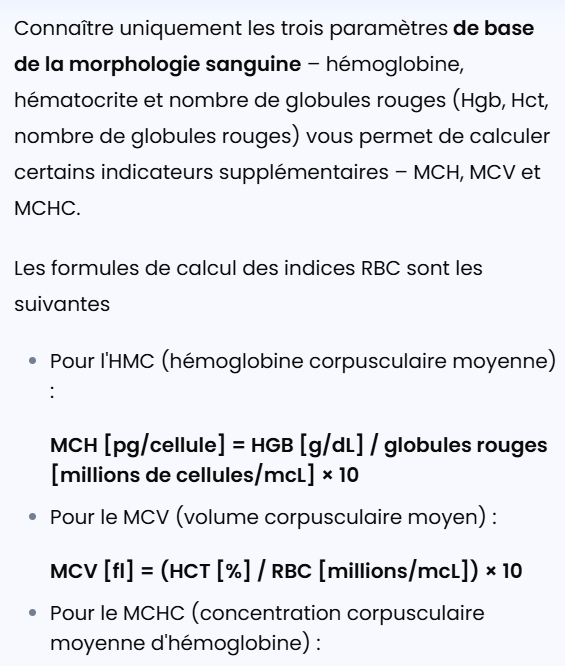

- **Ces 7 variables ne sont pas 7 mesures indépendantes.** L'automate en mesure 4 et calcule les 3 autres par une formule.

- **Mesuré :** `RBC`, `HGB`, `HCT`, `RDW`
- **Calculé :**

  | Variable | Formule | Vérification sur nos médianes |
  |---|---|---|
  | `MCV` | `HCT` / `RBC` × 10 | 34,3 / 3,9 × 10 = 87,9 ≈ 88,2 |
  | `MCH` | `HGB` / `RBC` × 10 | 11,4 / 3,9 × 10 = 29,2 ≈ 29,7 |
  | `MCHC` | `HGB` / `HCT` × 100 | 11,4 / 34,3 × 100 = 33,2 ≈ 33,5 |


*déduction de MCV par HCT et RBC*

In [29]:
df.select(
    MCV_recalcule=(pl.col("HCT") / pl.col("RBC") * 10).round(1),
    MCV_mesure=pl.col("MCV"),
).head(10)


MCV_recalcule,MCV_mesure
f64,f64
97.0,99.3
89.0,85.1
91.2,96.3
88.0,85.1
109.1,104.5
74.0,77.0
86.0,83.0
84.8,86.5
100.0,100.7


In [30]:
df.select(
    correlation=pl.corr(pl.col("MCV") * pl.col("RBC") / 10, pl.col("HCT")),
    ecart_moyen=(pl.col("MCV") * pl.col("RBC") / 10 - pl.col("HCT")).abs().mean().round(2),
)

correlation,ecart_moyen
f64,f64
0.988914,0.76


*déduction de MCH par HGB et RBC*

In [31]:
# déduction de MCH par HGB et RBC
df.select(
    MCH_recalcule=(pl.col("HGB") / pl.col("RBC") * 10).round(1),
    MCH_mesure=pl.col("MCH"),
).head(10)


MCH_recalcule,MCH_mesure
f64,f64
31.1,31.5
26.4,26.0
29.6,31.2
31.1,30.2
36.5,34.8
23.0,23.8
29.4,28.6
27.6,28.3
32.3,32.6


In [32]:
df.select(
    correlation=pl.corr(pl.col("HGB") / pl.col("RBC") * 10, pl.col("MCH")),
    ecart_moyen=(pl.col("HGB") / pl.col("RBC") * 10 - pl.col("MCH")).abs().mean().round(2),
)

correlation,ecart_moyen
f64,f64
0.937774,0.72


*déduction de MCHC par HGB et HCT*

In [33]:
# 21 hématocrites aberrants (13 à 0 et 8 entre 0,1 et 0,2) fausseraient la division
df.filter(pl.col("HCT") > 1).select(
    MCHC_recalcule=(pl.col("HGB") / pl.col("HCT") * 100).round(1),
    MCHC_mesure=pl.col("MCHC"),
).head(10)


MCHC_recalcule,MCHC_mesure
f64,f64
32.0,31.8
29.7,30.6
32.5,32.4
35.4,35.3
33.5,33.5
31.0,30.5
34.2,34.1
32.5,32.9
32.3,32.4


In [34]:
df.filter(pl.col("HCT") > 1).select(
    correlation=pl.corr(pl.col("HGB") / pl.col("HCT") * 100, pl.col("MCHC")).round(4),
    ecart_moyen=(pl.col("HGB") / pl.col("HCT") * 100 - pl.col("MCHC")).abs().mean().round(2),
)


correlation,ecart_moyen
f64,f64
0.9683,0.28


*matrice de corrélation de la lignée rouge*

In [35]:
# Les hématocrites aberrants et les lignes incomplètes sont écartés
ligne_rouge = ["RBC", "HGB", "HCT", "MCV", "MCH", "MCHC", "RDW"]

correlations = (
    df.filter(pl.col("HCT") > 1).select(ligne_rouge).drop_nulls().corr()
    .with_columns(variable=pl.Series(ligne_rouge))
    .select(["variable"] + ligne_rouge)
)

correlations.with_columns([pl.col(c).round(2) for c in ligne_rouge])


variable,RBC,HGB,HCT,MCV,MCH,MCHC,RDW
str,f64,f64,f64,f64,f64,f64,f64
"""RBC""",1.0,0.89,0.92,-0.34,-0.26,0.07,-0.3
"""HGB""",0.89,1.0,0.98,0.03,0.17,0.32,-0.44
"""HCT""",0.92,0.98,1.0,0.01,0.07,0.11,-0.37
"""MCV""",-0.34,0.03,0.01,1.0,0.88,0.07,-0.07
"""MCH""",-0.26,0.17,0.07,0.88,1.0,0.54,-0.26
"""MCHC""",0.07,0.32,0.11,0.07,0.54,1.0,-0.43
"""RDW""",-0.3,-0.44,-0.37,-0.07,-0.26,-0.43,1.0


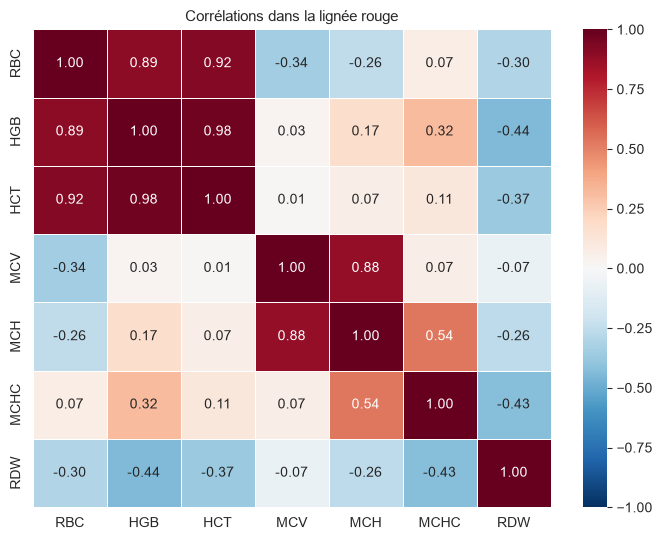

In [36]:
plt.figure(figsize=(7, 5.5))
sns.heatmap(
    correlations.select(ligne_rouge).to_numpy(),
    annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    xticklabels=ligne_rouge, yticklabels=ligne_rouge, linewidths=0.5,
)
plt.title("Corrélations dans la lignée rouge", fontsize=11)
plt.tight_layout()
plt.show()


**Ce que la matrice de corrélation montre, et ce qu'elle ne montre pas**

- **Les mesures liées entre elles ressortent nettement** : `HGB` et `HCT` sont corrélées à 0,98, `RBC` et `HCT` à 0,92, `MCV` et `MCH` à 0,88. Ces couples portent la même information.

- **Mais la matrice rate les vraies redondances** : `MCV` et `HCT` ne sont corrélées qu'à 0,01, alors que `MCV` se déduit exactement de `HCT` et `RBC`. La raison est simple : une corrélation ne mesure qu'un lien **linéaire entre deux variables**, alors qu'ici la relation est un rapport entre trois variables.

- **Conclusion de méthode** : la matrice de corrélation ne suffit pas à détecter ce type de redondance. Seul le recalcul par la formule, fait plus haut, la démontre.

**Recommandations selon le modèle**

- **Régression logistique, SVM, réseau de neurones** : ne garder que `RBC`, `HGB`, `HCT` et `RDW`. Deux colonnes dont l'une se déduit de l'autre rendent les coefficients instables (colinéarité) : le modèle ne sait pas à laquelle attribuer l'effet et peut produire des coefficients de signes opposés qui n'ont aucun sens clinique.

- **Random Forest, LightGBM, XGBoost** : les garder toutes est sans danger, ces modèles ignorent les colonnes redondantes. Seule conséquence, l'importance des variables se répartit entre les colonnes jumelles, ce qui sous-estime l'importance réelle de chacune.

- **Dans tous les cas** : tester les deux versions, avec et sans les variables calculées, et trancher au F1 en validation croisée.

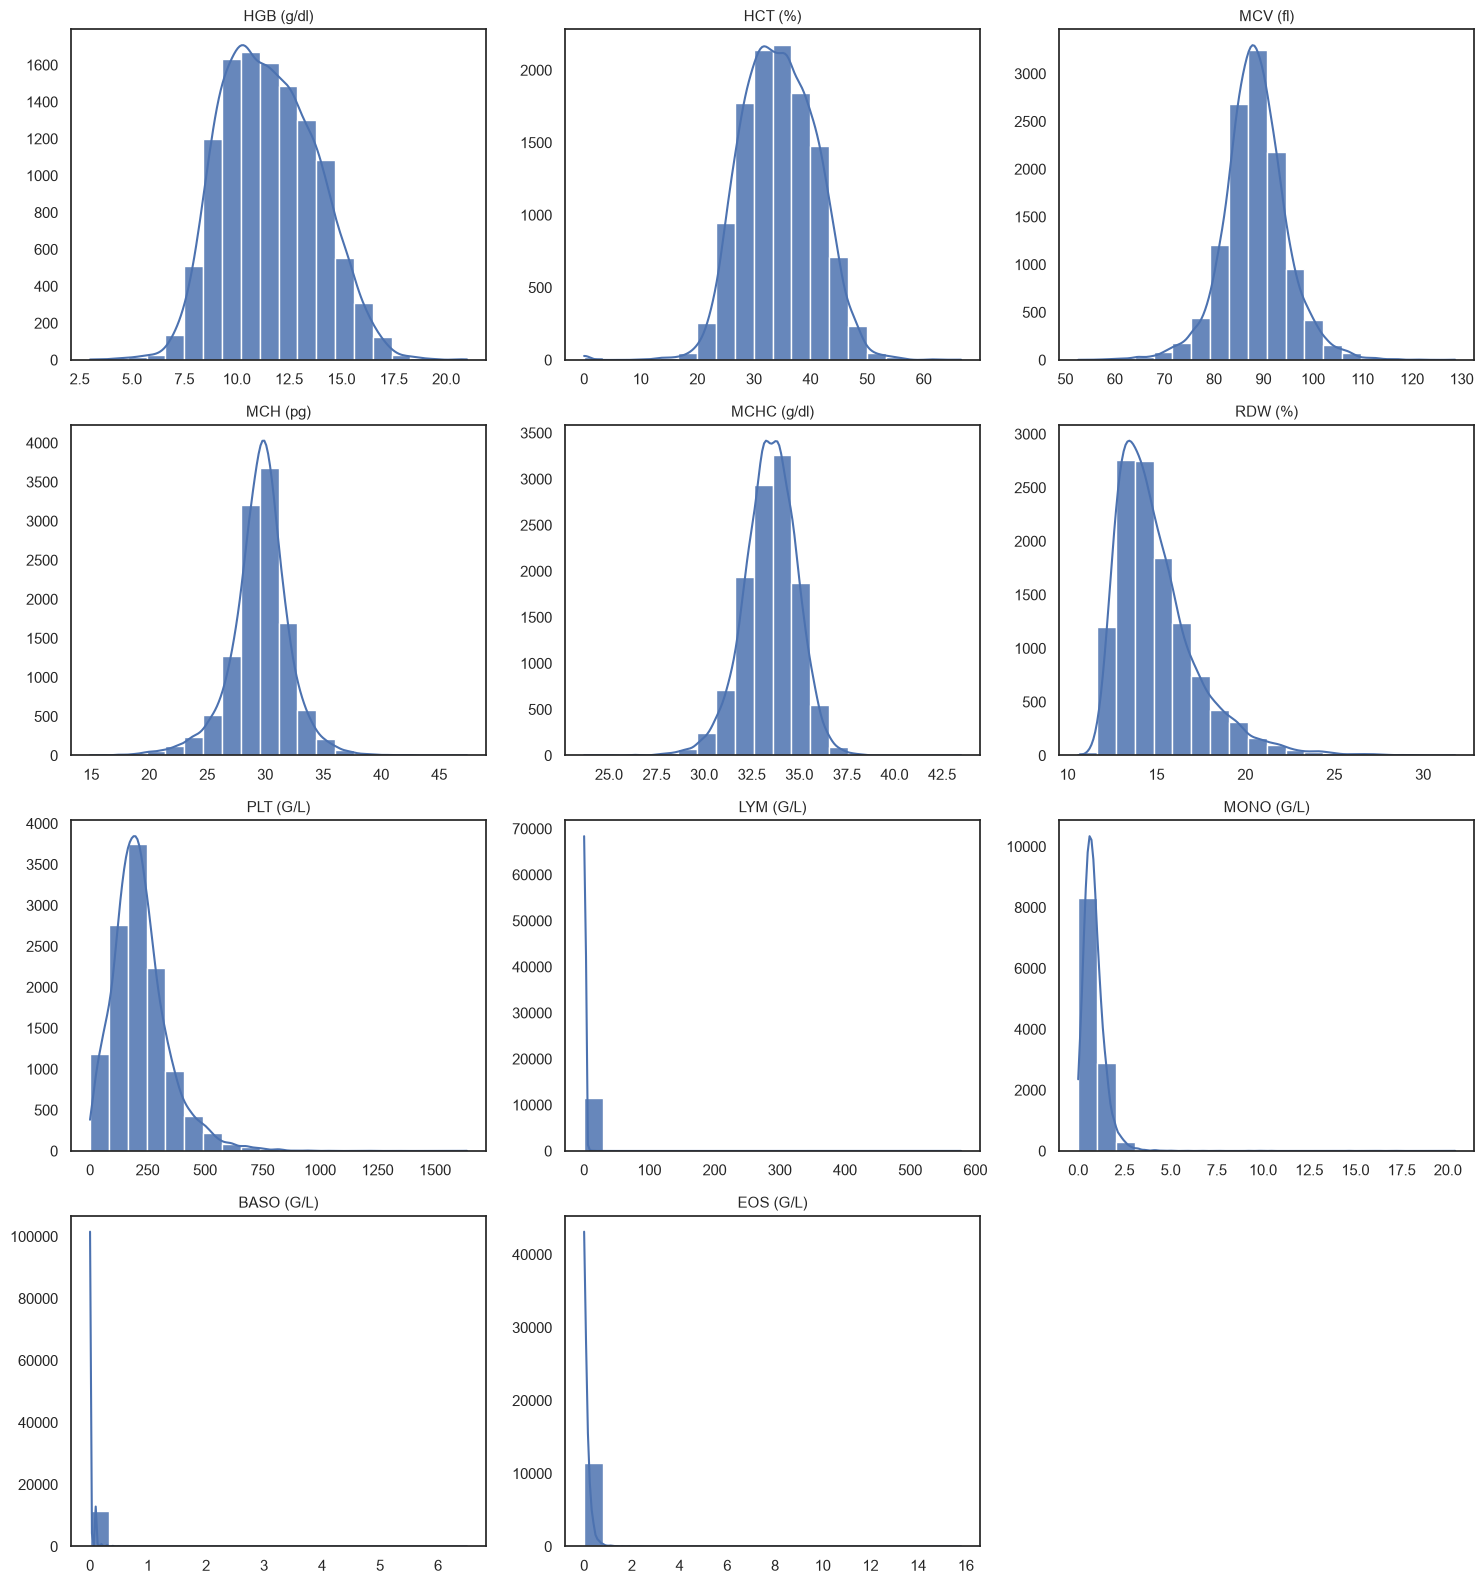

In [37]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1)

colonnes = df_hemo.columns
n = len(colonnes)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, colonnes):
    data = df_hemo[col].drop_nulls().to_numpy()

    sns.histplot(data, bins=20, kde=True, color="#4C72B0", alpha=0.85, ax=ax)

    ax.set_title(f"{col} ({unites[col]})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()

In [38]:
forme = pl.DataFrame({
    "variable": df_hemo.columns,
    "asymetrie": [df_hemo[c].skew() for c in df_hemo.columns],
    "kurtosis": [df_hemo[c].kurtosis() for c in df_hemo.columns],
}).sort("kurtosis", descending=True)

forme


variable,asymetrie,kurtosis
str,f64,f64
"""BASO""",42.962913,3068.276167
"""LYM""",52.120939,3003.020468
"""EOS""",26.982493,1276.682407
"""MONO""",7.475322,155.25715
"""PLT""",1.360954,4.833299
"""RDW""",1.597793,3.846528
"""MCH""",-0.402807,2.77077
"""MCV""",0.021809,2.171238
"""MCHC""",-0.406141,1.521237


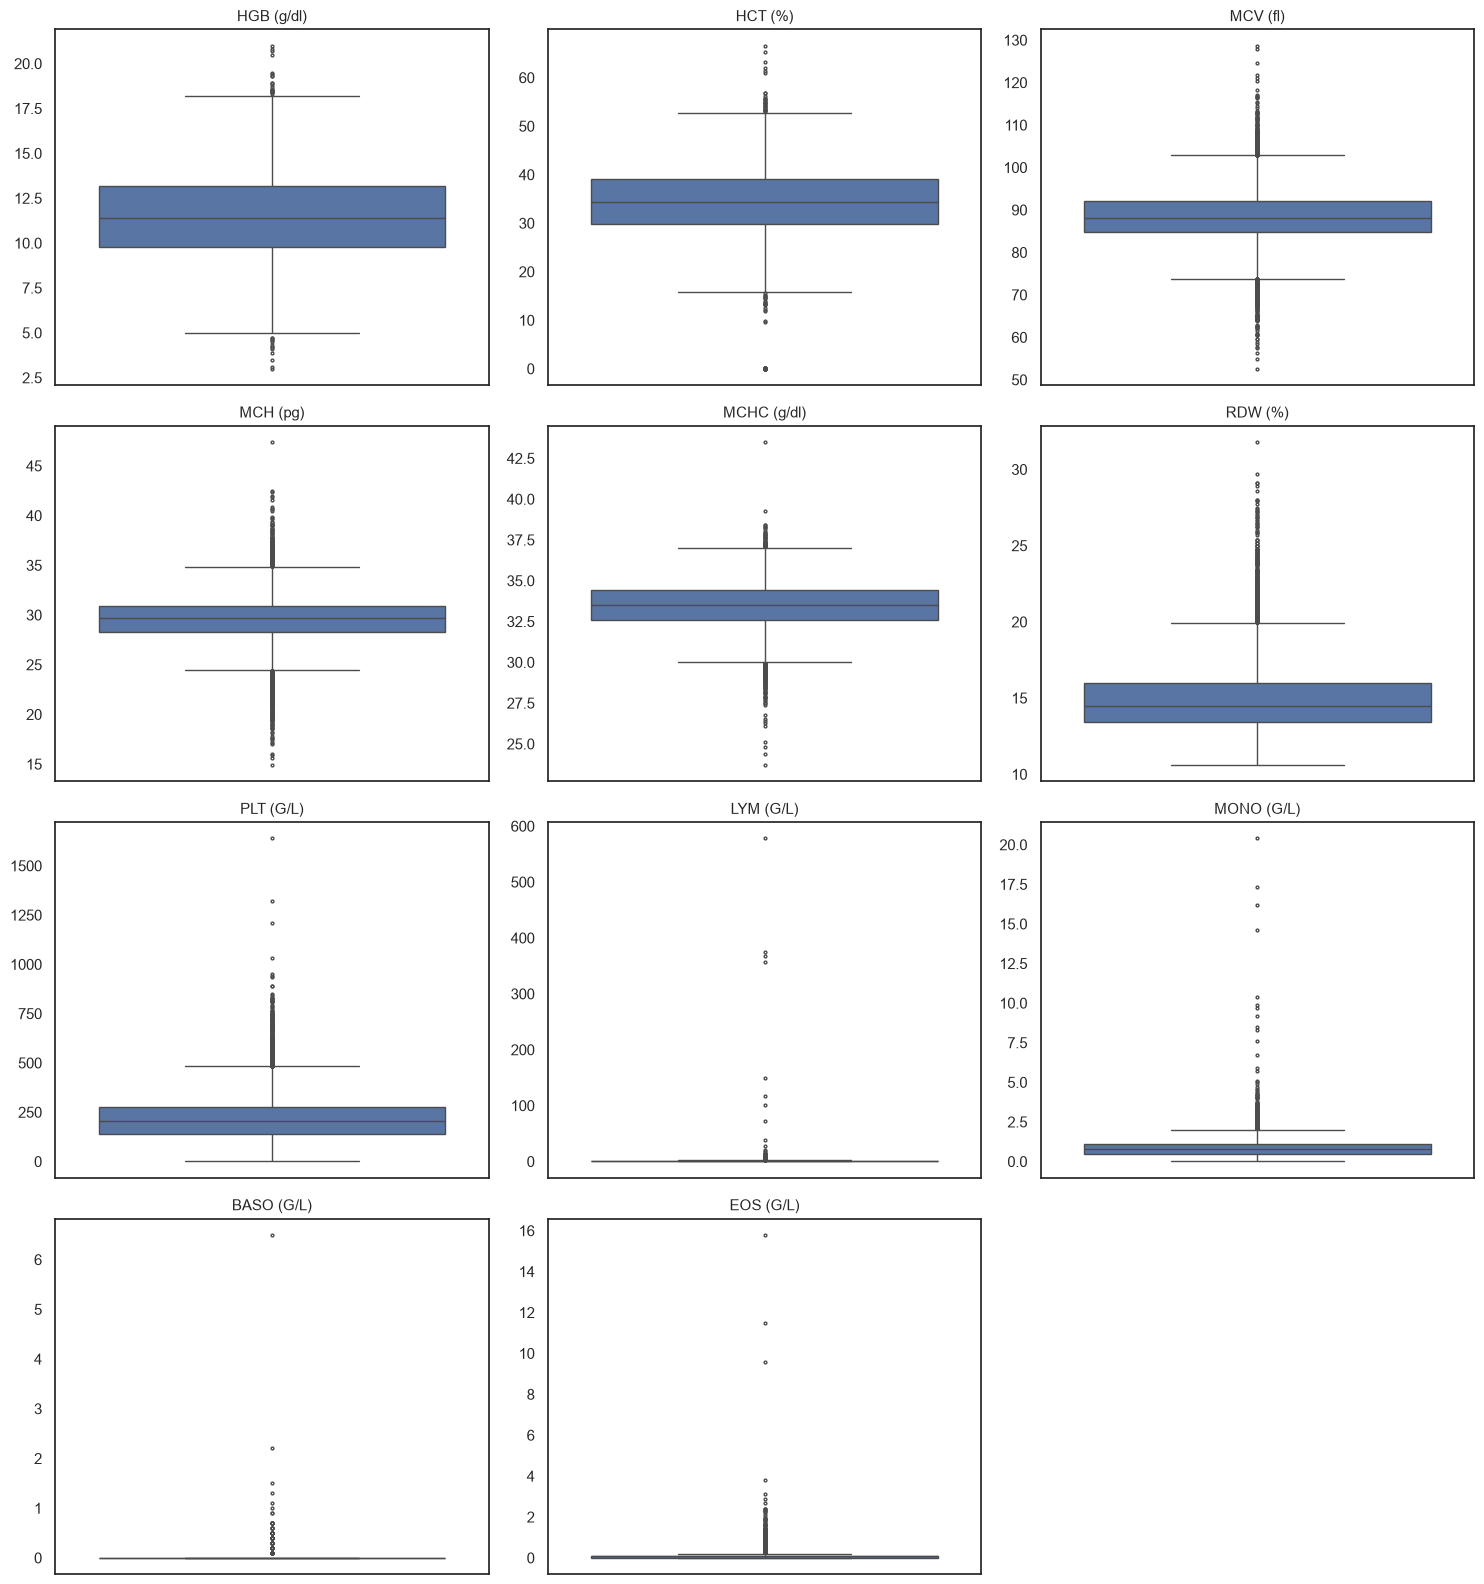

In [39]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1)

colonnes = df_hemo.columns
n = len(colonnes)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, colonnes):
    data = df_hemo[col].drop_nulls().to_numpy()

    sns.boxplot(y=data, color="#4C72B0", fliersize=2, ax=ax)

    ax.set_title(f"{col} ({unites[col]})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()


#### Lecture des graphiques de l'hémogramme

| Profil | Variables | Chiffres |
|---|---|---|
| En cloche, quasi normales | `HGB`, `HCT` | asymétrie < 0,25 ; kurtosis < 1 |
| Centrées, valeurs extrêmes des deux côtés | `MCV`, `MCH`, `MCHC` | asymétrie ≈ 0 ; kurtosis 1,5 à 2,8 |
| Étalées vers la droite | `RDW`, `PLT` | asymétrie 1,4 à 1,6 ; kurtosis 3,8 à 4,8 |
| Écrasées par leurs extrêmes | `LYM`, `MONO`, `EOS`, `BASO` | asymétrie 7 à 52 ; kurtosis jusqu'à 3 068 |

**Ce que cela veut dire**

- `HGB` et `HCT` sont bien réparties : rien à transformer.
- `MCV`, `MCH` et `MCHC` ont un pic étroit et des valeurs éparpillées des deux côtés. Ces extrêmes sont des anémies réelles, microcytaires d'un côté et macrocytaires de l'autre.
- `RDW` et `PLT` ont une longue queue à droite : à transformer par le logarithme.
- **Les histogrammes de `LYM`, `BASO`, `EOS` et `MONO` sont illisibles en échelle normale** : une seule barre apparaît, car quelques patients atteignent 578 G/L pour `LYM` alors que la médiane est à 1,0. C'est la démonstration qu'un passage au logarithme est indispensable pour ces variables.
- Sur les boxplots, `HCT` montre un amas de points près de 0 (les 21 valeurs aberrantes) et `MCHC` un point isolé à 43,5.

##### Groupe 3 : biochimie systématique

Trois analyses prescrites d'emblée devant une suspicion d'infection, manquantes chez environ 1 % des patients seulement.

In [40]:
biochimie = ["CRP", "CREA", "BUN"]
df_biochimie = df.select(biochimie)
df_biochimie.head()

CRP,CREA,BUN
f64,f64,f64
3.94,0.65,5.7
1.42,0.76,19.9
12.09,1.25,50.6
11.17,0.65,8.5
5.89,0.82,15.3


In [41]:
resume_manquants(df_biochimie)

variable,n_manquants,pct_manquants
str,u32,f64
"""BUN""",136,1.16
"""CREA""",124,1.06
"""CRP""",122,1.04


In [42]:
df_biochimie.describe()

statistic,CRP,CREA,BUN
str,f64,f64,f64
"""count""",11631.0,11629.0,11617.0
"""null_count""",122.0,124.0,136.0
"""mean""",11.027459,1.334635,22.73259
"""std""",9.601233,1.191337,18.199672
"""min""",0.0,0.26,2.5
"""25%""",2.99,0.82,11.7
"""50%""",8.69,1.0,16.6
"""75%""",16.71,1.34,27.1
"""max""",76.32,20.75,184.8


In [43]:
bornes_biochimie = {
    "CRP": (0, 0.5), "CREA": (0.6, 1.3), "BUN": (7, 20),
}
part_hors_norme(df_biochimie, bornes_biochimie)


variable,norme,sous_%,dans_%,au_dessus_%
str,str,f64,f64,f64
"""CRP""","""0 - 0.5""",0.0,7.4,92.6
"""CREA""","""0.6 - 1.3""",3.8,69.6,26.6
"""BUN""","""7 - 20""",4.5,57.1,38.4


In [44]:
# Part des patients dont la CRP dépasse 20 mg/dl, niveau d'infection bactérienne sévère
df_biochimie.select(
    part_crp_sup_20=(pl.col("CRP") > 20).mean().mul(100).round(1),
)


part_crp_sup_20
f64
17.7


**Valeurs usuelles et signification des écarts**

| Variable | Valeurs usuelles | En dessous | Au-dessus |
|---|---|---|---|
| `CRP` | moins de 0,5 mg/dl | Pas d'inflammation | Inflammation ou infection : c'est le marqueur central |
| `CREA` | 0,6–1,3 mg/dl | Peu significatif | Le rein filtre mal (insuffisance rénale) |
| `BUN` | 7–20 mg/dl | Dénutrition possible | Insuffisance rénale, déshydratation, catabolisme |

**Constats sur la biochimie systématique**

- **L'inflammation est quasi générale** : 93 % des patients ont une `CRP` au-dessus de la norme (inflammation), et seulement 7 % restent dans la norme. La médiane, à 8,69 mg/dl, est dix-sept fois la borne haute.

- **18 % des patients dépassent 20 mg/dl de CRP**, niveau qui évoque une infection bactérienne sévère. Attention cependant : une CRP élevée signe une inflammation, pas nécessairement une infection du sang.

- **La fonction rénale est altérée chez un quart à un tiers des patients** : 27 % ont une créatinine au-dessus de la norme et 38 % une urée élevée.

- **`CREA` et `BUN` sont très asymétriques** (asymétrie 5,1 et 2,5), avec des maxima à 20,75 et 184,8 : ce sont des insuffisances rénales sévères, valeurs réelles à conserver.

- **`CRP` est la moins déséquilibrée des trois** (asymétrie 1,10), car elle plafonne à 76,32 dans ce jeu de données.

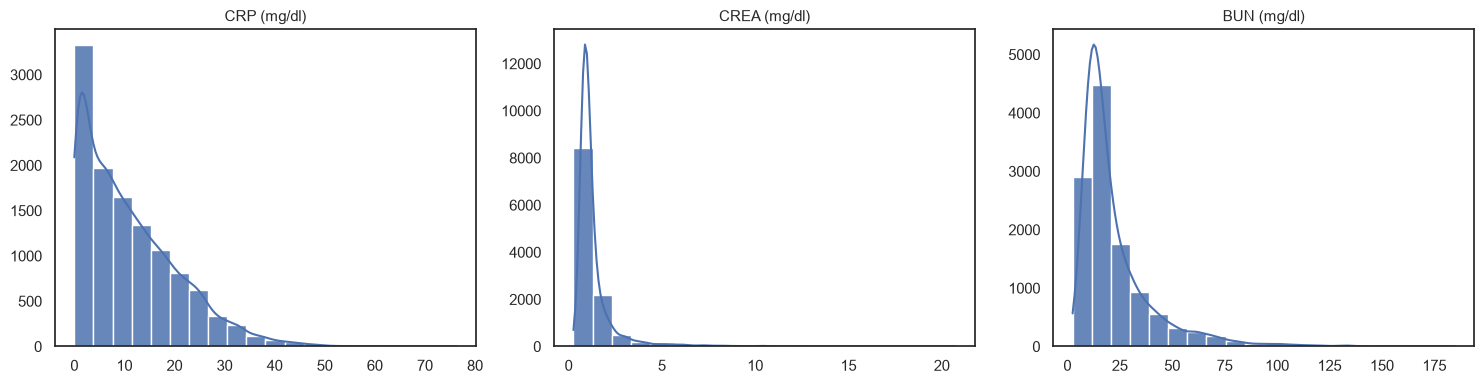

In [45]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1)

colonnes = df_biochimie.columns
n = len(colonnes)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, colonnes):
    data = df_biochimie[col].drop_nulls().to_numpy()

    sns.histplot(data, bins=20, kde=True, color="#4C72B0", alpha=0.85, ax=ax)

    ax.set_title(f"{col} ({unites[col]})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()

In [46]:
forme = pl.DataFrame({
    "variable": df_biochimie.columns,
    "asymetrie": [df_biochimie[c].skew() for c in df_biochimie.columns],
    "kurtosis": [df_biochimie[c].kurtosis() for c in df_biochimie.columns],
}).sort("kurtosis", descending=True)

forme


variable,asymetrie,kurtosis
str,f64,f64
"""CREA""",5.124529,38.439481
"""BUN""",2.537223,9.029117
"""CRP""",1.103173,1.21994


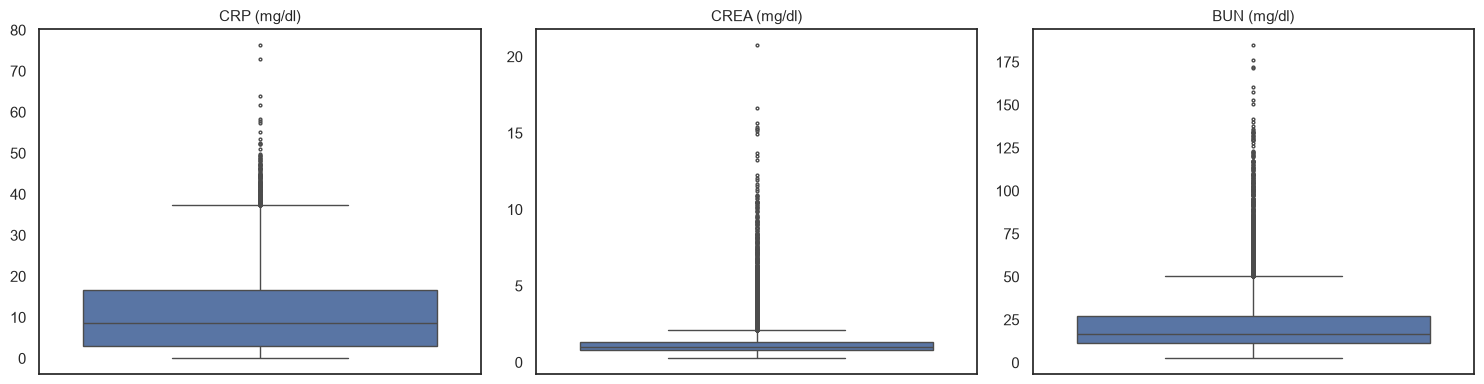

In [47]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1)

colonnes = df_biochimie.columns
n = len(colonnes)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, colonnes):
    data = df_biochimie[col].drop_nulls().to_numpy()

    sns.boxplot(y=data, color="#4C72B0", fliersize=2, ax=ax)

    ax.set_title(f"{col} ({unites[col]})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()


#### Lecture des graphiques de la biochimie

- **`CRP`** s'étale largement, sans pic étroit : presque tous les patients sont inflammatoires, à des degrés variés. C'est une variable bien répartie, donc exploitable telle quelle.
- **`CREA` et `BUN`** montrent une longue queue à droite et de nombreux points extrêmes au-dessus : à transformer par le logarithme.
- Aucune valeur impossible dans ce groupe : les minima (0,26 mg/dl de créatinine, 2,5 de BUN) sont bas mais plausibles.

##### Groupe 4 : formule leucocytaire détaillée

La formule détaillée est une étape supplémentaire de l'hémogramme, pas toujours réalisée.

In [48]:
formule_leuco = ["NEU", "NEUR", "LYMR", "MONOR", "BASOR", "EOSR", "RBC", "WBC"]
df_formule = df.select(formule_leuco)
df_formule.head()

NEU,NEUR,LYMR,MONOR,BASOR,EOSR,RBC,WBC
f64,f64,f64,f64,f64,f64,f64,f64
22.0,90.909091,1.652893,7.024793,0.413223,0.0,3.7,24.1
11.4,94.214876,3.305785,1.652893,0.0,0.826446,3.9,12.17
14.7,83.522727,8.522727,6.818182,0.568182,0.568182,2.5,17.45
8.4,87.5,8.333333,4.166667,0.0,0.0,4.4,9.86
6.8,68.0,22.0,9.0,0.0,1.0,4.3,9.94


In [49]:
resume_manquants(df_formule)


variable,n_manquants,pct_manquants
str,u32,f64
"""NEUR""",592,5.04
"""LYMR""",592,5.04
"""MONOR""",592,5.04
"""BASOR""",592,5.04
"""EOSR""",592,5.04
"""NEU""",588,5.0
"""WBC""",377,3.21
"""RBC""",375,3.19


In [50]:
df_formule.describe()

statistic,NEU,NEUR,LYMR,MONOR,BASOR,EOSR,RBC,WBC
str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",11165.0,11161.0,11161.0,11161.0,11161.0,11161.0,11378.0,11376.0
"""null_count""",588.0,592.0,592.0,592.0,592.0,592.0,375.0,377.0
"""mean""",8.376534,75.1899,14.586089,8.785591,0.144129,1.294291,3.933732,11.254335
"""std""",5.622108,15.553618,12.790056,5.772997,0.588816,2.363407,0.775366,13.625156
"""min""",0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
"""25%""",4.6,69.444444,6.741573,5.617978,0.0,0.0,3.4,6.65
"""50%""",7.3,78.472222,11.267606,8.0,0.0,0.568182,3.9,9.6
"""75%""",10.9,85.344828,18.181818,10.869565,0.0,1.785714,4.5,13.55
"""max""",83.8,100.0,100.0,100.0,23.655914,73.488372,7.7,604.47


In [51]:
bornes_formule = {
    "NEU": (1.8, 7), "NEUR": (40, 75), "LYMR": (20, 45), "MONOR": (2, 10),
    "BASOR": (0, 1), "EOSR": (1, 4), "RBC": (4.0, 5.9), "WBC": (4, 10),
}

part_hors_norme(df_formule, bornes_formule)


variable,norme,sous_%,dans_%,au_dessus_%
str,str,f64,f64,f64
"""NEU""","""1.8 - 7""",5.6,41.9,52.5
"""NEUR""","""40 - 75""",3.4,36.2,60.4
"""LYMR""","""20 - 45""",78.9,18.1,3.0
"""MONOR""","""2 - 10""",5.0,64.4,30.6
"""BASOR""","""0 - 1""",0.0,94.7,5.3
"""EOSR""","""1 - 4""",59.5,32.7,7.8
"""RBC""","""4.0 - 5.9""",51.3,48.2,0.5
"""WBC""","""4 - 10""",9.0,44.0,47.0


**Valeurs usuelles et signification des écarts**

| Variable | Valeurs usuelles | En dessous | Au-dessus |
|---|---|---|---|
| `WBC` | 4–10 G/L | Aplasie, sepsis grave, infection virale | Infection bactérienne, inflammation |
| `NEU` | 1,8–7 G/L | Neutropénie : risque infectieux majeur | Infection bactérienne |
| `NEUR` | 40–75 % | Peu fréquent | Polynucléose : profil typique de l'infection bactérienne |
| `LYMR` | 20–45 % | Lymphopénie relative : marqueur de gravité du sepsis | Infection virale, leucémie lymphoïde |
| `MONOR` | 2–10 % | Peu contributif | Infection prolongée |
| `BASOR` | 0–1 % | — | Rare : maladie de la moelle |
| `EOSR` | 1–4 % | Éosinopénie | Allergie, parasitose |
| `RBC` | 4,0–5,9 T/L | Anémie | Polyglobulie, déshydratation |

**Constats sur la formule leucocytaire** (pourcentages issus de la cellule ci-dessus)

- **Le profil est celui d'une infection bactérienne, et il est majoritaire** : 60 % des patients ont un `NEUR` au-dessus de la norme, et **79 % ont un `LYMR` en dessous**, soit près de quatre patients sur cinq. Les neutrophiles prennent la place des lymphocytes.

- **Ces deux variables sont les plus prometteuses du groupe**, car la majorité des patients y est hors norme, ce qui est rare.

- **Près d'un patient sur deux a une hyperleucocytose** : 47 % dépassent 10 G/L de globules blancs, et 9 % sont en dessous de 4.

- **Les monocytes sont élevés chez 31 % des patients**, ce qui accompagne les infections prolongées.

- **Un patient sur deux est anémique** : 51 % ont un `RBC` sous la norme, ce qui confirme l'anémie déjà vue sur l'hémoglobine.

- **`BASOR` et `EOSR` apportent peu** : 95 % des patients sont dans la norme pour `BASOR`, et `EOSR` est surtout en dessous de la norme (60 %).

- **Attention à la redondance** : les pourcentages se déduisent des valeurs absolues divisées par `WBC`. Les cellules qui suivent le vérifient.

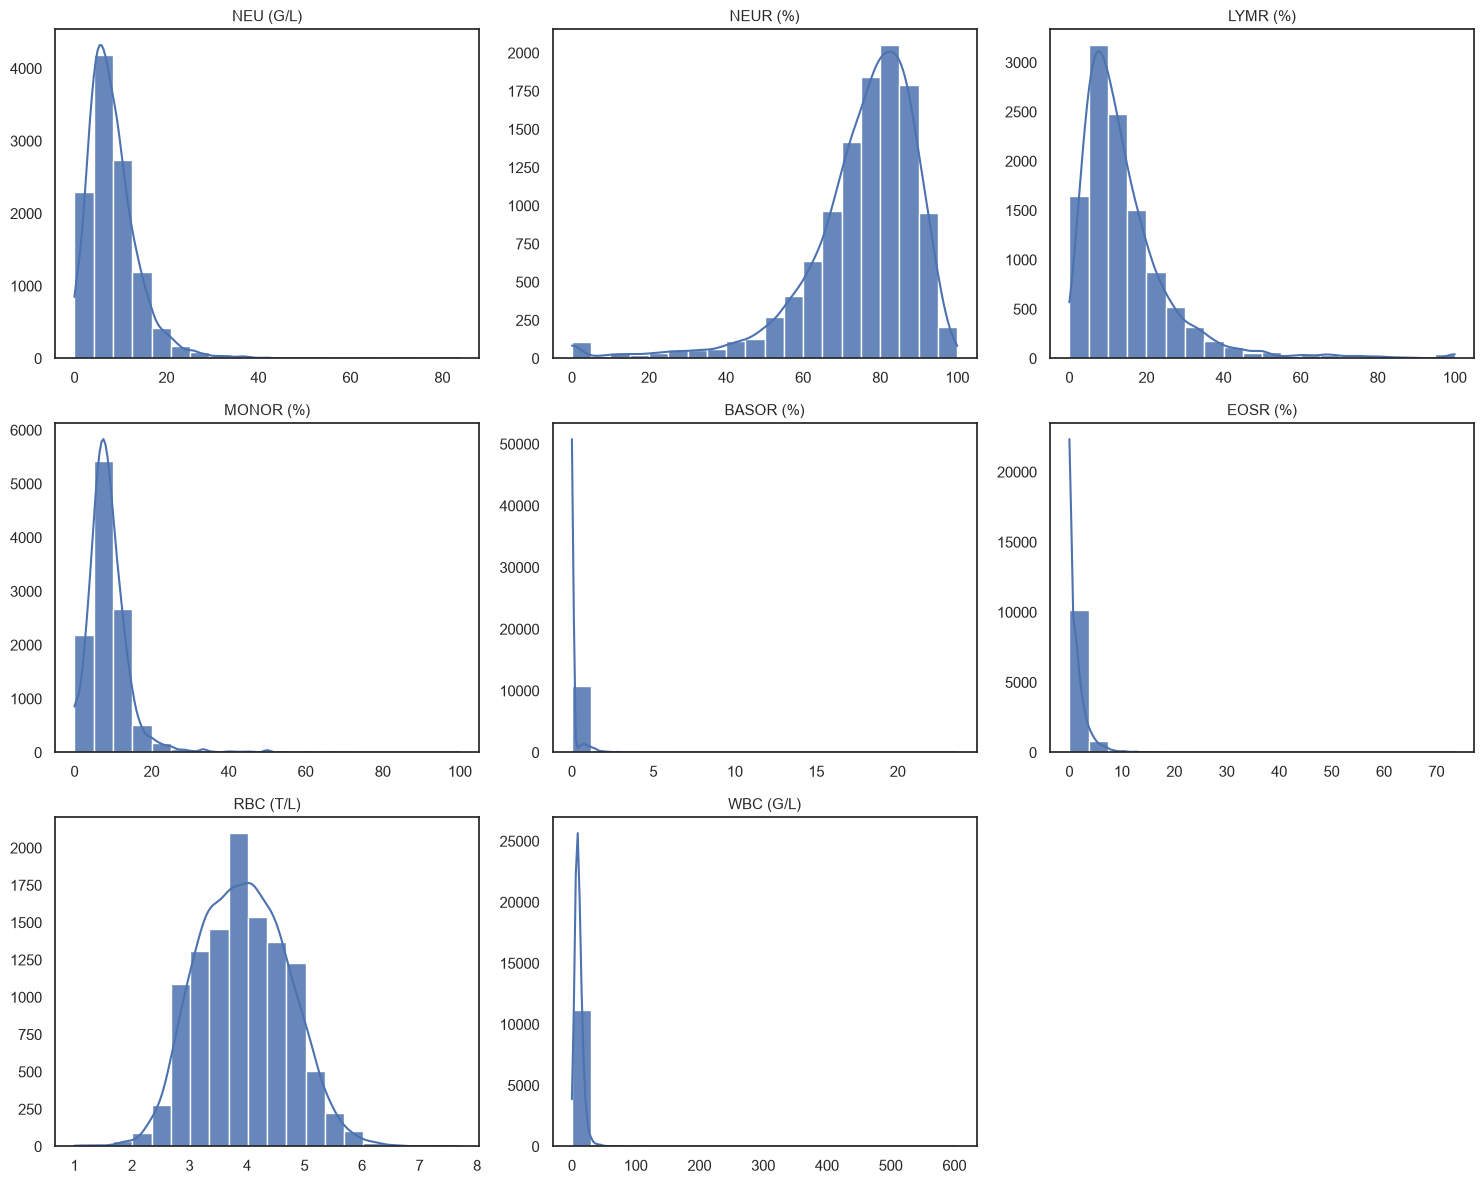

In [52]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1)

colonnes = df_formule.columns
n = len(colonnes)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, colonnes):
    data = df_formule[col].drop_nulls().to_numpy()

    sns.histplot(data, bins=20, kde=True, color="#4C72B0", alpha=0.85, ax=ax)

    ax.set_title(f"{col} ({unites[col]})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()


In [53]:
forme = pl.DataFrame({
    "variable": df_formule.columns,
    "asymetrie": [df_formule[c].skew() for c in df_formule.columns],
    "kurtosis": [df_formule[c].kurtosis() for c in df_formule.columns],
}).sort("kurtosis", descending=True)

forme

variable,asymetrie,kurtosis
str,f64,f64
"""WBC""",20.531654,634.945622
"""BASOR""",13.376578,360.439936
"""EOSR""",7.524747,134.513869
"""MONOR""",3.661343,30.348616
"""LYMR""",2.855635,12.075561
"""NEU""",2.003793,10.037683
"""NEUR""",-1.993077,5.911129
"""RBC""",0.132236,-0.096931


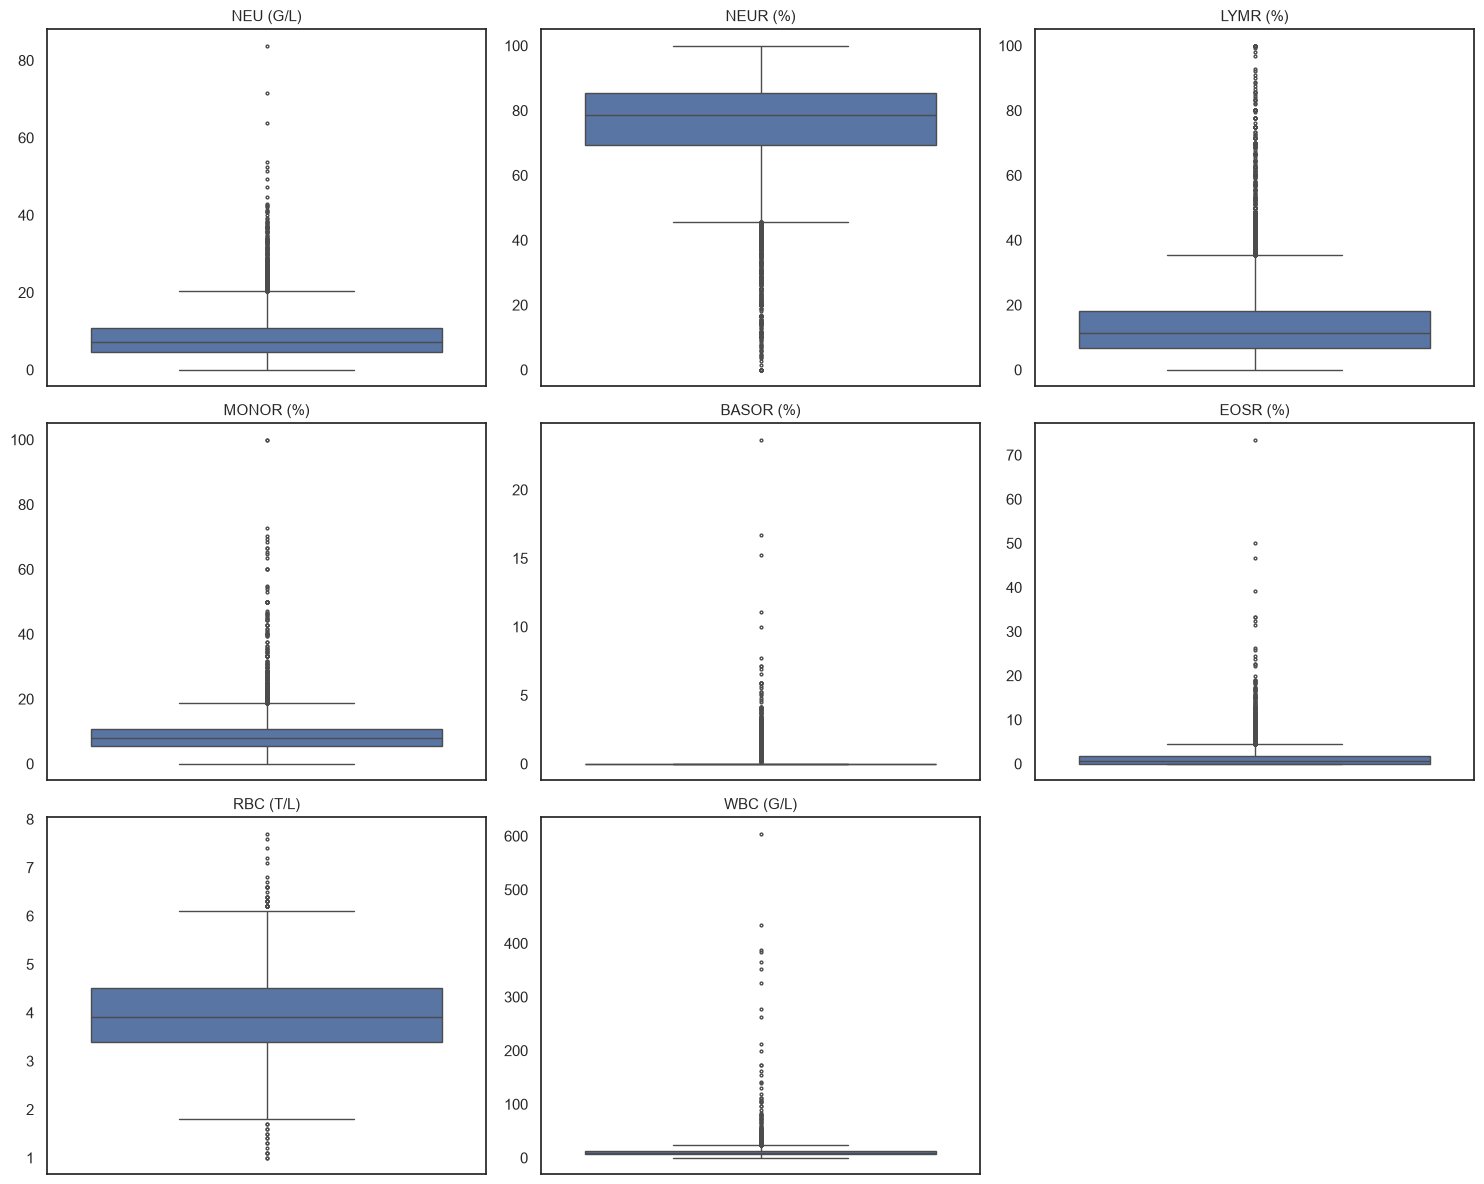

In [54]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1)

colonnes = df_formule.columns
n = len(colonnes)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, colonnes):
    data = df_formule[col].drop_nulls().to_numpy()

    sns.boxplot(y=data, color="#4C72B0", fliersize=2, ax=ax)

    ax.set_title(f"{col} ({unites[col]})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()


#### Lecture des graphiques de la formule leucocytaire

- **`NEUR`** est la seule variable asymétrique **à gauche** de tout le jeu de données (asymétrie −1,99) : la plupart des patients sont proches du plafond de 100 %, et la queue s'étire vers les valeurs basses.
- **`LYMR` et `MONOR`** ont une longue queue à droite, avec quelques patients à 100 %.
- **`RBC`** est la variable la plus normale du groupe (asymétrie 0,13, kurtosis −0,10) : une belle cloche.
- **`WBC`, `BASOR` et `EOSR` sont illisibles en échelle normale** : leurs kurtosis de 135 à 635 signalent des valeurs isolées très éloignées. Le logarithme est indispensable.

*vérification : chaque pourcentage est-il le rapport de la valeur absolue sur `WBC` ?*

In [55]:
df.select(
    NEUR_recalcule=(pl.col("NEU") / pl.col("WBC") * 100).round(1),
    NEUR_mesure=pl.col("NEUR"),
).head(10)


NEUR_recalcule,NEUR_mesure
f64,f64
91.3,90.909091
93.7,94.214876
84.2,83.522727
85.2,87.5
68.4,68.0
67.4,66.666667
63.5,63.333333
86.8,85.416667
35.5,29.411765


In [56]:
# WBC vaut 0 chez un patient : la division donnerait l'infini, on l'écarte
for absolue, pourcentage in [("NEU", "NEUR"), ("LYM", "LYMR"), ("MONO", "MONOR"), ("EOS", "EOSR"), ("BASO", "BASOR")]:
    print(
        pourcentage,
        df.filter(pl.col("WBC") > 0).select(
            correlation=pl.corr(pl.col(absolue) / pl.col("WBC") * 100, pl.col(pourcentage)).round(4),
            ecart_moyen=(pl.col(absolue) / pl.col("WBC") * 100 - pl.col(pourcentage)).abs().mean().round(2),
        ).row(0),
    )


NEUR (0.978, 1.42)
LYMR (0.9562, 0.66)
MONOR (0.9327, 0.29)
EOSR (0.9953, 0.03)
BASOR (0.997, 0.0)


In [57]:
# La formule détaillée manque-t-elle plus souvent quand les globules blancs sont extrêmes ?
df.group_by(pl.col("LYMR").is_null().alias("LYMR_manquant")).agg(
    n=pl.len(),
    WBC_mediane=pl.col("WBC").median(),
    WBC_max=pl.col("WBC").max(),
).sort("LYMR_manquant")


LYMR_manquant,n,WBC_mediane,WBC_max
bool,u32,f64,f64
false,11161,9.53,155.04
true,592,20.69,604.47


**Ce que montre la vérification**

- **Les cinq pourcentages sont bien le rapport de la valeur absolue sur `WBC`** : corrélations de 0,93 à 0,997 et écarts moyens inférieurs à 1,5 point. Les écarts résiduels viennent du bruit d'anonymisation des données. Ce groupe contient donc l'information deux fois, en valeur absolue et en proportion. Pour un modèle linéaire, il faut choisir l'une des deux formes.

- **Chez les patients dont les globules blancs dépassent 100 G/L, la formule détaillée manque presque toujours** : seuls 3 des 25 patients concernés ont un `LYMR`. Pour ces trois-là, il vaut de 84 à 97 %, ce qui correspond à une leucémie lymphoïde.

- **Ce manquant n'est pas un hasard, c'est un signal.** La cellule ci-dessus le montre : quand `LYMR` manque, la médiane des globules blancs est de 20,7 G/L contre 9,5 sinon, et le maximum atteint 604 contre 155. L'automate ne rend pas la formule quand la numération est trop anormale. L'absence de la formule est donc un marqueur de gravité, et un nouvel exemple de mécanisme MNAR.

*deuxième approche : `NEUR` est-il le complément des quatre autres pourcentages ?*

La somme des cinq pourcentages leucocytaires doit valoir 100 %. L'automate en déduit donc le dernier : `NEUR` = 100 − (`LYMR` + `MONOR` + `EOSR` + `BASOR`).

In [58]:
autres = pl.col("LYMR") + pl.col("MONOR") + pl.col("EOSR") + pl.col("BASOR")

df.drop_nulls(["NEUR", "LYMR", "MONOR", "EOSR", "BASOR"]).select(
    correlation=pl.corr(100 - autres, pl.col("NEUR")).round(6),
    ecart_moyen=(100 - autres - pl.col("NEUR")).abs().mean().round(4),
    ecart_max=(100 - autres - pl.col("NEUR")).abs().max().round(4),
)


correlation,ecart_moyen,ecart_max
f64,f64,f64
1.0,0.0,0.0


In [59]:
# Comparaison des deux formules, cote a cote
df.drop_nulls(["NEUR", "LYMR", "MONOR", "EOSR", "BASOR", "NEU", "WBC"]).select(
    NEUR_mesure=pl.col("NEUR").round(2),
    par_complement=(100 - autres).round(2),
    par_rapport_WBC=(pl.col("NEU") / pl.col("WBC") * 100).round(2),
).head(6)


NEUR_mesure,par_complement,par_rapport_WBC
f64,f64,f64
90.91,90.91,91.29
94.21,94.21,93.67
83.52,83.52,84.24
87.5,87.5,85.19
68.0,68.0,68.41
66.67,66.67,67.42


**Les deux formules ne se valent pas**

| Formule | Corrélation | Écart moyen |
|---|---|---|
| `NEUR` = 100 − (`LYMR` + `MONOR` + `EOSR` + `BASOR`) | **1,000000** | **0,00** |
| `NEUR` = `NEU` / `WBC` × 100 | 0,978 | 1,42 point |

- **La première est exacte pour 100 % des patients**, à la précision machine près. La somme des cinq pourcentages vaut exactement 100 partout.

- **La seconde est seulement approchée**, parce que le bruit d'anonymisation a été appliqué séparément à `NEU` et à `WBC`. Les pourcentages, eux, ont été conservés cohérents entre eux.

- **Conséquence pour la modélisation** : `NEUR` n'apporte aucune information que les quatre autres pourcentages ne contiennent déjà. C'est une dépendance linéaire parfaite, le même piège que les variables indicatrices d'une catégorie. Garder les cinq rend la matrice singulière et les coefficients d'une régression logistique non identifiables. **Il faut en retirer un**, `BASOR` par exemple, qui est presque constant.

- Pour les modèles à base d'arbres, aucun risque, mais la variable reste inutile.

**Variable construite : le rapport neutrophiles sur lymphocytes**

Nos deux meilleures variables disent la même chose séparément : `NEUR` est élevé chez 60 % des patients et `LYMR` bas chez 79 %. Leur rapport condense ce profil en une seule colonne, et c'est un marqueur d'infection bactérienne documenté en clinique.

Un arbre de décision ne découpe que sur une variable à la fois (`NEU > 7`, puis `LYM < 1`) : il approxime donc un rapport par un escalier, ce qui demande beaucoup de découpes. Lui fournir le rapport directement lui épargne ce travail.

**Mais le rapport ne remplace pas ses composantes.** Deux patients très différents peuvent avoir le même rapport :

| Patient | `NEU` | `LYM` | Rapport | Situation clinique |
|---|---|---|---|---|
| A | 10 G/L | 1 G/L | 10 | Hyperleucocytose : la moelle réagit fortement |
| B | 1 G/L | 0,1 G/L | 10 | Neutropénie profonde : la moelle est épuisée |

Le rapport porte la **forme** du profil leucocytaire, les valeurs absolues portent son **niveau**. Le patient B est bien plus grave, et sans `NEU` ni `WBC` à côté, le modèle ne peut pas les distinguer. On ajoute donc le rapport, sans retirer ses composantes.

In [60]:
# Apercu du rapport. La colonne sera creee pour de bon au pre-processing.
# LYM vaut 0 chez quelques patients, d'ou le + 0.01 qui evite la division par zero.
df.select(
    "NEU", "LYM",
    ratio_neu_lym=(pl.col("NEU") / (pl.col("LYM") + 0.01)).round(2),
).head()

# Autres rapports cliniques a tester ensuite :
#   ratio_plt_lym  = PLT / LYM    -> marqueur d'inflammation
#   ratio_crp_alb  = CRP / ALB    -> inflammation rapportee a l'etat nutritionnel
#                                    (93 % ont une CRP elevee et 57 % une albumine basse)
#   ratio_bun_crea = BUN / CREA   -> distingue deshydratation et atteinte renale


NEU,LYM,ratio_neu_lym
f64,f64,f64
22.0,0.4,53.66
11.4,0.4,27.8
14.7,1.5,9.74
8.4,0.8,10.37
6.8,2.2,3.08


##### Groupe 5 : indices plaquettaires

Deux indices calculés par l'automate en marge de la numération plaquettaire.

In [61]:
plaquettes_indices = ["MPV", "PDW"]
df_plaquette = df.select(plaquettes_indices)
df_plaquette.head()


MPV,PDW
f64,f64
10.8,10.6
9.7,11.4
11.1,14.1
10.0,12.2
10.9,12.9


In [62]:
resume_manquants(df_plaquette)


variable,n_manquants,pct_manquants
str,u32,f64
"""PDW""",889,7.56
"""MPV""",565,4.81


In [63]:
df_plaquette.describe()

statistic,MPV,PDW
str,f64,f64
"""count""",11188.0,10864.0
"""null_count""",565.0,889.0
"""mean""",10.375313,12.281858
"""std""",1.005771,2.181033
"""min""",7.3,6.6
"""25%""",9.7,10.8
"""50%""",10.3,12.0
"""75%""",11.0,13.4
"""max""",15.0,25.3


In [64]:
bornes_plaquette = {
    "MPV": (7.5, 11.5), "PDW": (9, 17),
}

part_hors_norme(df_plaquette, bornes_plaquette)


variable,norme,sous_%,dans_%,au_dessus_%
str,str,f64,f64,f64
"""MPV""","""7.5 - 11.5""",0.0,87.3,12.7
"""PDW""","""9 - 17""",2.5,94.0,3.5


**Valeurs usuelles et signification des écarts**

| Variable | Valeurs usuelles | En dessous | Au-dessus |
|---|---|---|---|
| `MPV` | 7,5–11,5 fl | Plaquettes petites : la moelle en fabrique mal | Plaquettes grandes et jeunes : la moelle remplace celles qui sont détruites |
| `PDW` | 9–17 % | Plaquettes de taille homogène | Plaquettes de tailles très variables : renouvellement en cours |

**Constats sur les indices plaquettaires**

- **La grande majorité des patients est dans la norme** : 87 % pour `MPV` et 94 % pour `PDW`. Ce sont les deux variables les plus normales de l'analyse.

- **13 % ont un `MPV` élevé**, signe que la moelle fabrique des plaquettes jeunes pour compenser une destruction.

- **`MPV` varie très peu** : écart-type de 1,0 pour une médiane de 10,3, ce qui en fait la variable la plus stable du jeu de données.

- **Aucune valeur impossible** : les minima (7,3 fl et 6,6 %) sont plausibles.

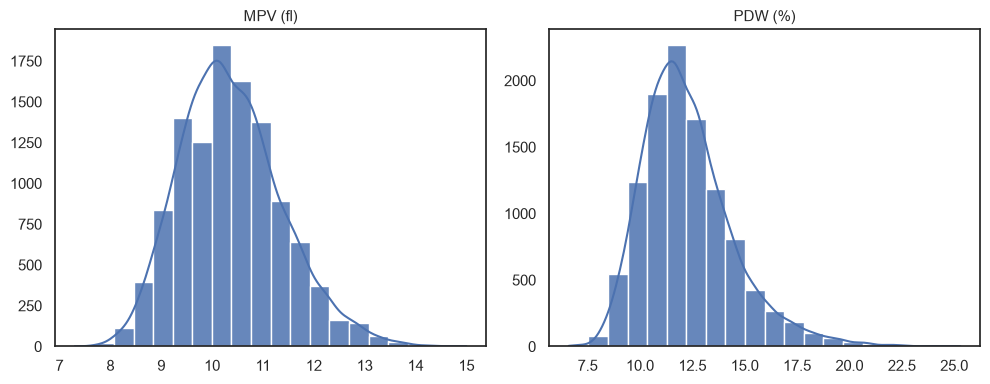

In [65]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1)

colonnes = df_plaquette.columns
n = len(colonnes)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, colonnes):
    data = df_plaquette[col].drop_nulls().to_numpy()

    sns.histplot(data, bins=20, kde=True, color="#4C72B0", alpha=0.85, ax=ax)

    ax.set_title(f"{col} ({unites[col]})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()


In [66]:
forme = pl.DataFrame({
    "variable": df_plaquette.columns,
    "asymetrie": [df_plaquette[c].skew() for c in df_plaquette.columns],
    "kurtosis": [df_plaquette[c].kurtosis() for c in df_plaquette.columns],
}).sort("kurtosis", descending=True)

forme


variable,asymetrie,kurtosis
str,f64,f64
"""PDW""",1.026913,1.893133
"""MPV""",0.46097,0.216998


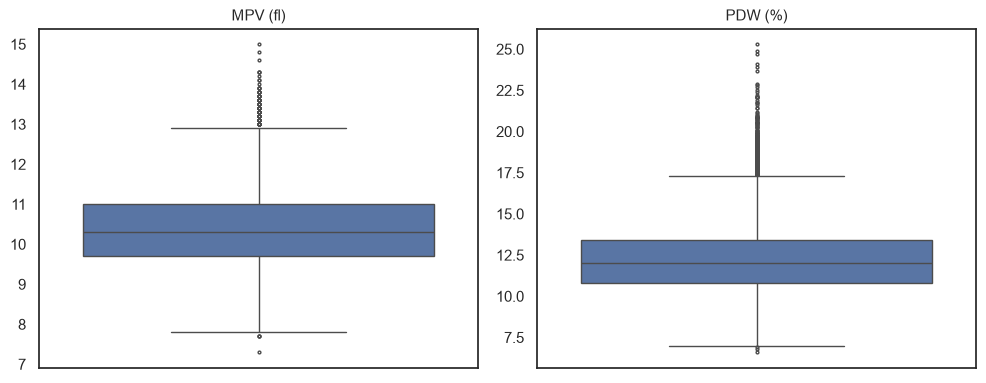

In [67]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1)

colonnes = df_plaquette.columns
n = len(colonnes)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, colonnes):
    data = df_plaquette[col].drop_nulls().to_numpy()

    sns.boxplot(y=data, color="#4C72B0", fliersize=2, ax=ax)

    ax.set_title(f"{col} ({unites[col]})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()


In [68]:
# Les patients dont les indices manquent ont-ils moins de plaquettes ?
for indice in ["PDW", "MPV"]:
    print(
        df.group_by(pl.col(indice).is_null().alias(f"{indice}_manquant")).agg(
            n=pl.len(),
            PLT_mediane=pl.col("PLT").median(),
            part_thrombopenie=(pl.col("PLT") < 150).mean().round(3),
        ).sort(f"{indice}_manquant")
    )


shape: (2, 4)
┌──────────────┬───────┬─────────────┬───────────────────┐
│ PDW_manquant ┆ n     ┆ PLT_mediane ┆ part_thrombopenie │
│ ---          ┆ ---   ┆ ---         ┆ ---               │
│ bool         ┆ u32   ┆ f64         ┆ f64               │
╞══════════════╪═══════╪═════════════╪═══════════════════╡
│ false        ┆ 10864 ┆ 210.0       ┆ 0.25              │
│ true         ┆ 889   ┆ 85.0        ┆ 0.687             │
└──────────────┴───────┴─────────────┴───────────────────┘
shape: (2, 4)
┌──────────────┬───────┬─────────────┬───────────────────┐
│ MPV_manquant ┆ n     ┆ PLT_mediane ┆ part_thrombopenie │
│ ---          ┆ ---   ┆ ---         ┆ ---               │
│ bool         ┆ u32   ┆ f64         ┆ f64               │
╞══════════════╪═══════╪═════════════╪═══════════════════╡
│ false        ┆ 11188 ┆ 209.0       ┆ 0.254             │
│ true         ┆ 565   ┆ 55.0        ┆ 0.861             │
└──────────────┴───────┴─────────────┴───────────────────┘


#### Lecture des graphiques des indices plaquettaires

- **`MPV`** dessine une cloche presque parfaite (asymétrie 0,46, kurtosis 0,22) : rien à transformer.
- **`PDW`** a une queue droite modérée : le logarithme est optionnel.
- Les boxplots montrent peu de points extrêmes, uniquement au-dessus : ce sont les deux variables les plus sages de l'analyse.

**Le manquant de ce groupe est fortement informatif**

La cellule de comparaison ci-dessus le démontre :

| | Plaquettes médianes | Part en thrombopénie |
|---|---|---|
| `PDW` présent | 210 G/L | 25 % |
| `PDW` manquant | 85 G/L | 69 % |
| `MPV` présent | 209 G/L | 25 % |
| `MPV` manquant | 55 G/L | 86 % |

Les patients dont l'automate n'a pas calculé les indices ont des plaquettes quatre fois plus basses, et 86 % d'entre eux sont en thrombopénie quand `MPV` manque, contre 25 % sinon.

**L'explication est technique** : avec trop peu de plaquettes, l'automate n'a pas assez de cellules pour mesurer une taille moyenne fiable. Mais la conséquence est statistique : **l'absence de ces indices signale une thrombopénie sévère**, donc un patient plus grave.

C'est le cas de MNAR le plus net du jeu de données, et l'indicateur de manquant de ce groupe doit absolument être conservé.

##### Groupe 6 : coagulation

Le bilan de coagulation est demandé en cas de risque hémorragique, de gravité, ou avant un geste invasif.

- `FIB` Un dosage du fibrinogène est utilisé pour diagnostiquer des troubles de la coagulation, évaluer les risques de thrombose ou de saignement, et servir de marqueur de l'inflammation. 
- `APTT` est un test sanguin de dépistage qui mesure la durée nécessaire à la formation d'un caillot de sang via la voie intrinsèque et la voie commune de la cascade de coagulation. 
- `NT` Le Normotest est un test de coagulation sanguine utilisé principalement pour évaluer la fonction hépatique (foie) et détecter les carences en facteurs de coagulation dépendants de la vitamine K.

In [69]:
coagulation = ["NT", "APTT", "FIB"]
df_coag = df.select(coagulation)
df_coag.head()


NT,APTT,FIB
i64,f64,i64
86,28.8,578
90,29.8,null
58,36.3,313
95,33.1,490
61,41.8,400


In [70]:
resume_manquants(df_coag)


variable,n_manquants,pct_manquants
str,u32,f64
"""FIB""",2065,17.57
"""APTT""",2052,17.46
"""NT""",1979,16.84


In [71]:
df_coag.describe()


statistic,NT,APTT,FIB
str,f64,f64,f64
"""count""",9774.0,9701.0,9688.0
"""null_count""",1979.0,2052.0,2065.0
"""mean""",83.117148,40.173869,550.198596
"""std""",27.165392,11.094636,207.554111
"""min""",4.0,21.4,60.0
"""25%""",67.0,34.2,399.0
"""50%""",83.0,37.8,532.0
"""75%""",101.0,42.8,675.0
"""max""",152.0,176.1,1593.0


In [72]:
bornes_coag = {
    "NT": (70, 130), "APTT": (30, 40), "FIB": (200, 400),
}

part_hors_norme(df_coag, bornes_coag)


variable,norme,sous_%,dans_%,au_dessus_%
str,str,f64,f64,f64
"""NT""","""70 - 130""",29.1,66.8,4.1
"""APTT""","""30 - 40""",4.7,59.2,36.1
"""FIB""","""200 - 400""",2.3,23.0,74.8


**Valeurs usuelles et signification des écarts**

| Variable | Valeurs usuelles | En dessous | Au-dessus |
|---|---|---|---|
| `NT` | 70–130 % | Le sang coagule mal : insuffisance hépatique, anticoagulants, coagulation intravasculaire disséminée | Sans signification |
| `APTT` | 30–40 sec | Sans signification | Le sang coagule mal : héparine, déficit en facteurs |
| `FIB` | 200–400 mg/dl | Consommation du fibrinogène : forme grave | Inflammation : protéine de la phase aiguë |

**Constats sur la coagulation**

- **Trois patients sur quatre ont un fibrinogène élevé** : 75 % dépassent 400 mg/dl. C'est la signature de l'inflammation aiguë, et l'écart le plus massif de tous les groupes.

- **Un patient sur trois a un temps de céphaline allongé** : 36 % dépassent 40 secondes.

- **29 % coagulent mal** : `NT` sous 70 %, ce qui traduit une atteinte hépatique ou une coagulopathie. Le minimum descend à 4 %.

- **`NT` est la variable la plus symétrique du jeu de données** : asymétrie −0,16 et kurtosis −0,04, soit une distribution quasi normale.

- **`FIB` descend à 60 mg/dl** chez les patients les plus graves : c'est une consommation du fibrinogène, valeur réelle et de mauvais pronostic.

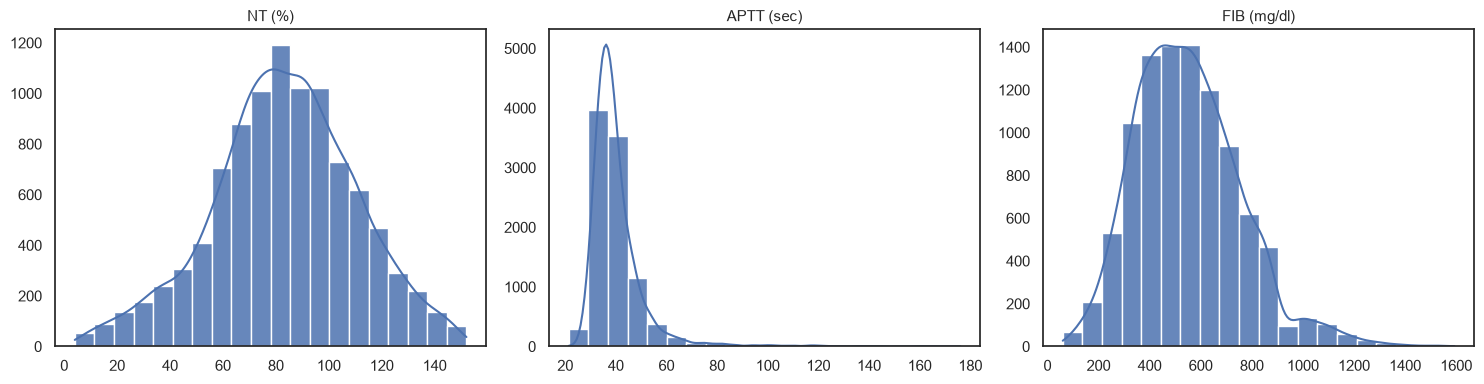

In [73]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1)

colonnes = df_coag.columns
n = len(colonnes)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, colonnes):
    data = df_coag[col].drop_nulls().to_numpy()

    sns.histplot(data, bins=20, kde=True, color="#4C72B0", alpha=0.85, ax=ax)

    ax.set_title(f"{col} ({unites[col]})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()


In [74]:
forme = pl.DataFrame({
    "variable": df_coag.columns,
    "asymetrie": [df_coag[c].skew() for c in df_coag.columns],
    "kurtosis": [df_coag[c].kurtosis() for c in df_coag.columns],
}).sort("kurtosis", descending=True)

forme


variable,asymetrie,kurtosis
str,f64,f64
"""APTT""",4.147696,29.077956
"""FIB""",0.654307,0.802534
"""NT""",-0.163068,-0.040146


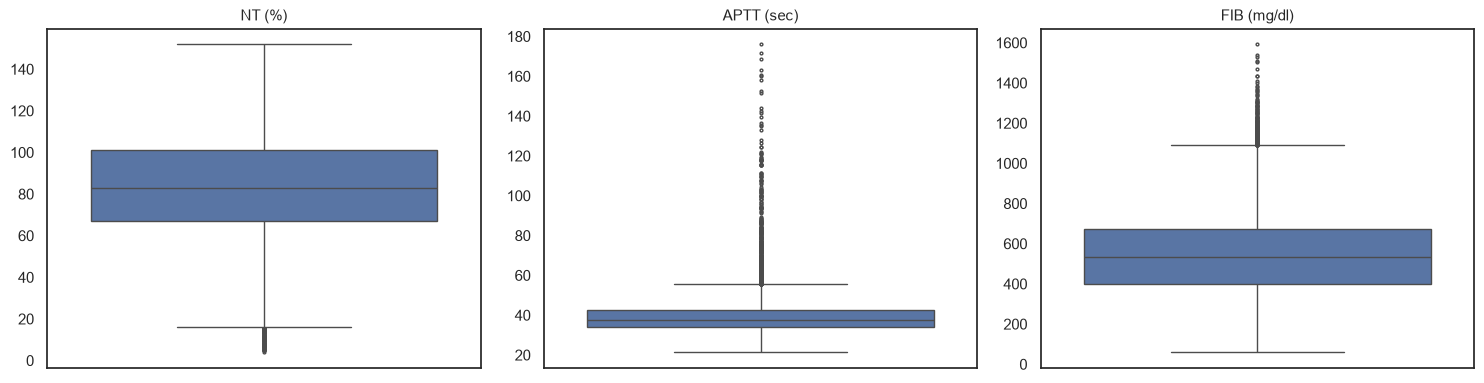

In [75]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1)

colonnes = df_coag.columns
n = len(colonnes)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, colonnes):
    data = df_coag[col].drop_nulls().to_numpy()

    sns.boxplot(y=data, color="#4C72B0", fliersize=2, ax=ax)

    ax.set_title(f"{col} ({unites[col]})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()


#### Lecture des graphiques de la coagulation

- **`NT`** dessine une cloche large et régulière : aucune transformation nécessaire.
- **`FIB`** est légèrement étalée à droite (asymétrie 0,65) et se lit facilement.
- **`APTT`** est la seule variable problématique du groupe (asymétrie 4,15, kurtosis 29) : sa queue droite écrase l'histogramme, le logarithme est utile.

##### Groupe 7 : ionogramme et minéraux


In [76]:
ionogramme = ["SODIUM", "POTASS", "MG", "CA", "PHOS"]
df_iono = df.select(ionogramme)
df_iono.head()

SODIUM,POTASS,MG,CA,PHOS
i64,f64,f64,f64,f64
137,3.88,0.66,2.29,1.2
141,null,null,2.21,0.58
147,4.61,1.03,1.92,1.51
137,null,0.74,2.34,0.97
141,4.41,0.56,2.08,0.99


In [77]:
resume_manquants(df_iono)


variable,n_manquants,pct_manquants
str,u32,f64
"""POTASS""",1606,13.66
"""MG""",1513,12.87
"""SODIUM""",1042,8.87
"""CA""",1029,8.76
"""PHOS""",997,8.48


In [78]:
df_iono.describe()

statistic,SODIUM,POTASS,MG,CA,PHOS
str,f64,f64,f64,f64,f64
"""count""",10711.0,10147.0,10240.0,10724.0,10756.0
"""null_count""",1042.0,1606.0,1513.0,1029.0,997.0
"""mean""",137.20605,4.003089,0.814354,2.213206,1.048325
"""std""",4.774233,0.648146,0.150559,0.203588,0.396064
"""min""",106.0,1.92,0.2,1.15,0.3
"""25%""",135.0,3.67,0.73,2.09,0.81
"""50%""",137.0,3.95,0.81,2.22,0.99
"""75%""",140.0,4.29,0.89,2.34,1.21
"""max""",170.0,36.62,2.22,4.4,6.22


In [79]:
bornes_iono = {
    "SODIUM": (136, 145), "POTASS": (3.5, 5), "MG": (0.7, 1.0),
    "CA": (2.2, 2.6), "PHOS": (0.8, 1.45),
}

part_hors_norme(df_iono, bornes_iono)


variable,norme,sous_%,dans_%,au_dessus_%
str,str,f64,f64,f64
"""SODIUM""","""136 - 145""",30.9,66.0,3.1
"""POTASS""","""3.5 - 5""",14.5,81.3,4.1
"""MG""","""0.7 - 1.0""",17.9,74.0,8.1
"""CA""","""2.2 - 2.6""",44.4,54.0,1.6
"""PHOS""","""0.8 - 1.45""",23.3,66.2,10.4


**Valeurs usuelles et signification des écarts**

| Variable | Valeurs usuelles | En dessous | Au-dessus |
|---|---|---|---|
| `SODIUM` | 136–145 mmol/L | Hyponatrémie : fréquente dans les infections aiguës | Déshydratation |
| `POTASS` | 3,5–5,0 mmol/L | Pertes digestives, diurétiques | Insuffisance rénale ; au-delà de 6,5 c'est une urgence vitale |
| `MG` | 0,7–1,0 mmol/L | Dénutrition, alcool, diurétiques | Insuffisance rénale |
| `CA` | 2,20–2,60 mmol/L | Hypocalcémie : fréquente au cours du sepsis | Cancer, hyperparathyroïdie |
| `PHOS` | 0,8–1,45 mmol/L | Dénutrition | Insuffisance rénale, lyse cellulaire |

**Constats sur l'ionogramme**

- **L'hypocalcémie touche 44 % des patients**, ce qui est décrit au cours du sepsis. C'est l'anomalie la plus fréquente du groupe.

- **31 % sont en hyponatrémie** (`SODIUM` sous 136 mmol/L), et le minimum descend à 106, valeur sévère mais réelle.

- **23 % ont un phosphate bas et 18 % un magnésium bas**, profil habituel des patients dénutris.

- **Le potassium est le plus souvent normal** (81 % dans la norme)

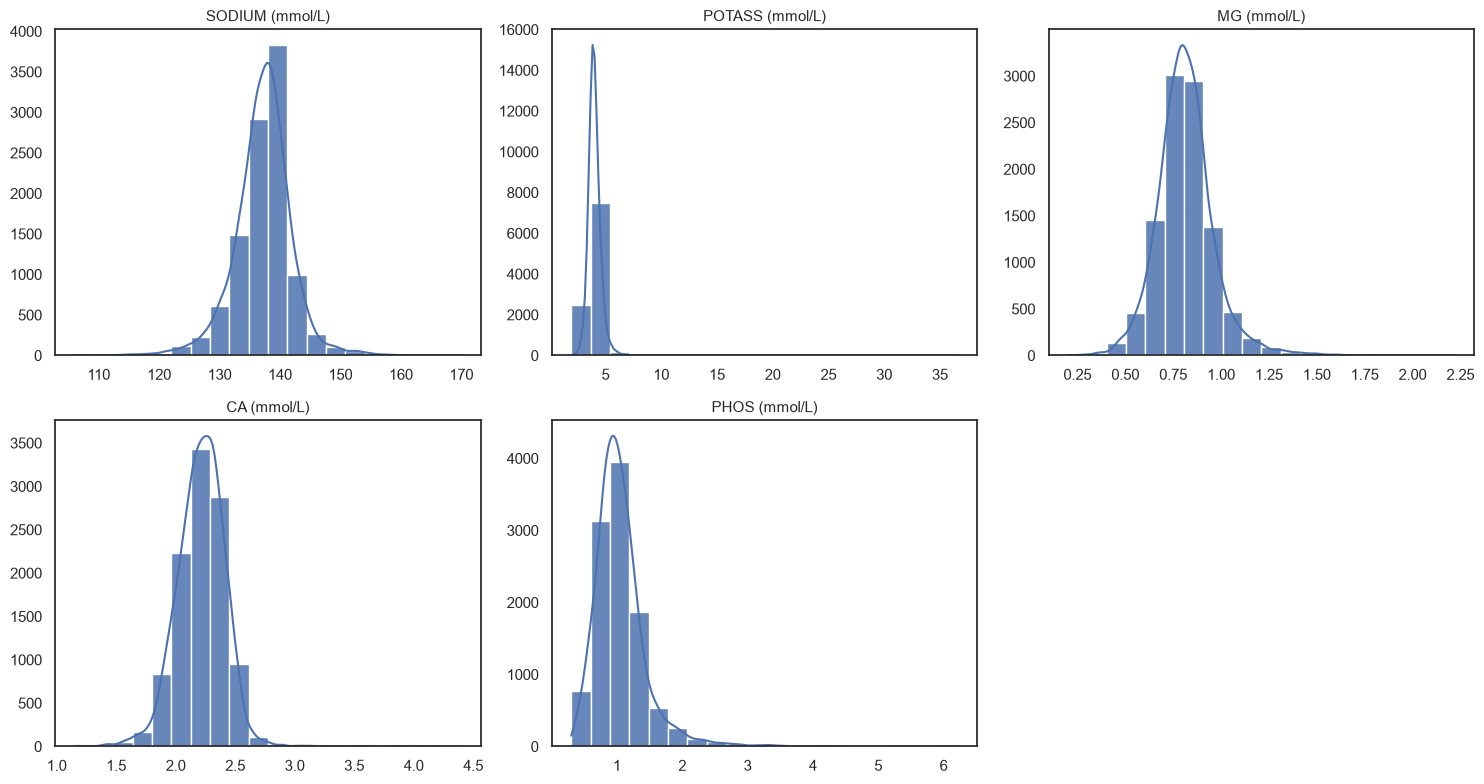

In [80]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1)

colonnes = df_iono.columns
n = len(colonnes)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, colonnes):
    data = df_iono[col].drop_nulls().to_numpy()

    sns.histplot(data, bins=20, kde=True, color="#4C72B0", alpha=0.85, ax=ax)

    ax.set_title(f"{col} ({unites[col]})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()


In [81]:
forme = pl.DataFrame({
    "variable": df_iono.columns,
    "asymetrie": [df_iono[c].skew() for c in df_iono.columns],
    "kurtosis": [df_iono[c].kurtosis() for c in df_iono.columns],
}).sort("kurtosis", descending=True)

forme


variable,asymetrie,kurtosis
str,f64,f64
"""POTASS""",13.605257,640.780026
"""PHOS""",2.180132,11.499525
"""CA""",0.206867,4.924789
"""MG""",0.890381,4.266739
"""SODIUM""",-0.210898,3.280498


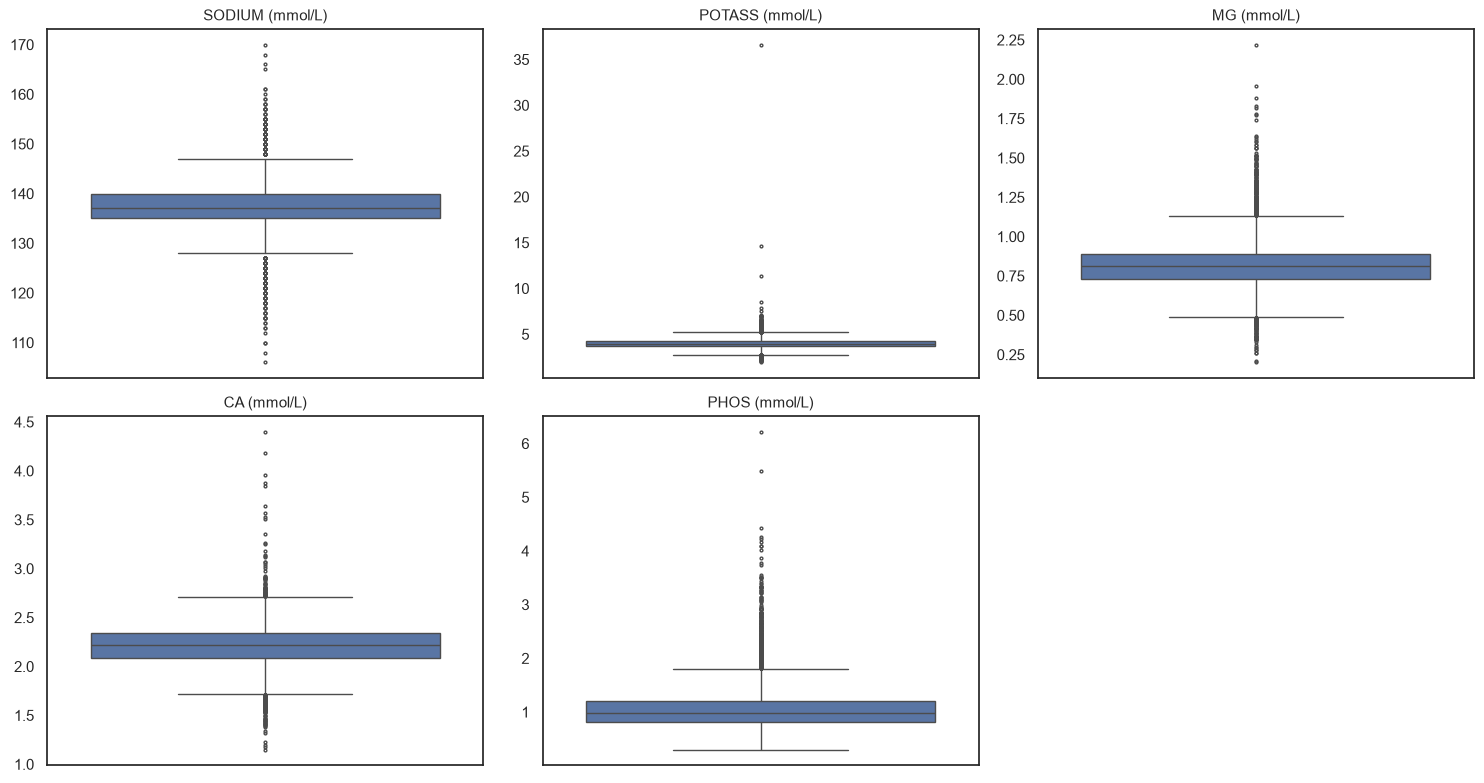

In [82]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1)

colonnes = df_iono.columns
n = len(colonnes)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, colonnes):
    data = df_iono[col].drop_nulls().to_numpy()

    sns.boxplot(y=data, color="#4C72B0", fliersize=2, ax=ax)

    ax.set_title(f"{col} ({unites[col]})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()


#### Lecture des graphiques de l'ionogramme

- **`SODIUM` et `CA`** sont presque symétriques (asymétrie −0,21 et 0,21) mais avec des kurtosis de 3,3 et 4,9 : un pic étroit et des valeurs extrêmes des deux côtés, comme pour les indices érythrocytaires. Ce sont des paramètres étroitement régulés par l'organisme.
- **`PHOS` et `MG`** ont une queue droite modérée.
- **`POTASS` est illisible** : sa kurtosis de 641. 
- Sur les boxplots, les points extrêmes du potassium se détachent très nettement, ce qui les rend faciles à repérer.

##### Groupe 8 : foie et protéines

Le bilan hépatique complet, prescrit ensemble quand une atteinte du foie est suspectée.

In [83]:
foie = ["GGT", "ASAT", "ALAT", "AP", "GBIL", "CHE", "ALB", "TP"]
df_foie = df.select(foie)
df_foie.head()


GGT,ASAT,ALAT,AP,GBIL,CHE,ALB,TP
i64,i64,i64,i64,f64,f64,f64,f64
48,22,14,85,0.59,5.12,36.7,67.0
61,28,25,80,0.48,5.61,37.4,65.3
134,124,135,119,8.42,2.52,22.1,40.5
72,35,22,108,0.42,6.91,43.8,78.4
68,32,11,68,2.4,6.79,30.1,57.5


In [84]:
resume_manquants(df_foie)


variable,n_manquants,pct_manquants
str,u32,f64
"""CHE""",1974,16.8
"""ALB""",1343,11.43
"""TP""",1282,10.91
"""GBIL""",1151,9.79
"""AP""",1125,9.57
"""GGT""",1010,8.59
"""ASAT""",920,7.83
"""ALAT""",788,6.7


In [85]:
df_foie.describe()


statistic,GGT,ASAT,ALAT,AP,GBIL,CHE,ALB,TP
str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",10743.0,10833.0,10965.0,10628.0,10602.0,9779.0,10410.0,10471.0
"""null_count""",1010.0,920.0,788.0,1125.0,1151.0,1974.0,1343.0,1282.0
"""mean""",114.595923,85.070341,65.890378,118.645559,1.405543,4.773301,33.357618,64.801031
"""std""",206.864542,379.64402,285.420837,132.384119,2.754676,2.09956,7.434086,11.431761
"""min""",3.0,5.0,0.0,11.0,0.12,0.98,10.0,29.9
"""25%""",25.0,22.0,16.0,62.0,0.53,3.12,27.8,56.8
"""50%""",49.0,31.0,26.0,84.0,0.76,4.59,33.5,65.7
"""75%""",118.0,57.0,48.0,123.0,1.23,6.21,39.0,73.3
"""max""",5171.0,12079.0,12329.0,2995.0,51.77,13.89,55.7,120.9


In [86]:
bornes_foie = {
    "GGT": (0, 55), "ASAT": (0, 40), "ALAT": (0, 45), "AP": (40, 130),
    "GBIL": (0.2, 1.2), "CHE": (5, 12), "ALB": (35, 50), "TP": (60, 80),
}

part_hors_norme(df_foie, bornes_foie)


variable,norme,sous_%,dans_%,au_dessus_%
str,str,f64,f64,f64
"""GGT""","""0 - 55""",0.0,53.9,46.1
"""ASAT""","""0 - 40""",0.0,62.7,37.3
"""ALAT""","""0 - 45""",0.0,73.2,26.8
"""AP""","""40 - 130""",3.7,73.9,22.4
"""GBIL""","""0.2 - 1.2""",0.2,73.9,25.8
"""CHE""","""5 - 12""",56.8,43.1,0.2
"""ALB""","""35 - 50""",56.8,42.9,0.3
"""TP""","""60 - 80""",32.9,59.7,7.4


**Valeurs usuelles et signification des écarts**

| Variable | Valeurs usuelles | En dessous | Au-dessus |
|---|---|---|---|
| `ASAT` | moins de 40 U/L | — | Souffrance du foie, du muscle, ou manque d'oxygène (choc) |
| `ALAT` | moins de 45 U/L | — | Souffrance du foie, plus spécifique que `ASAT` |
| `GGT` | moins de 55 U/L | — | Obstacle sur les voies biliaires, alcool, médicaments |
| `AP` | 40–130 U/L | — | Obstacle biliaire, atteinte osseuse |
| `GBIL` | 0,2–1,2 mg/dl | — | Ictère : obstacle biliaire, destruction des globules rouges, foie défaillant |
| `CHE` | 5–12 kU/L | Le foie fabrique mal : insuffisance hépatique, dénutrition, inflammation | — |
| `ALB` | 35–50 g/L | Inflammation, dénutrition, fuite des protéines : mauvais pronostic | Déshydratation |
| `TP` | 60–80 g/L | Dénutrition, fuite des protéines | Déshydratation |

**Constats sur le bilan hépatique** (pourcentages issus de la cellule ci-dessus)

- **Plus de la moitié des patients a une albumine basse (57 %) et une cholinestérase basse (57 %)**. Ces deux protéines sont fabriquées par le foie : leur baisse simultanée traduit l'inflammation et la dénutrition. C'est un marqueur reconnu de gravité.

- **La cholestase est fréquente** : 46 % ont une `GGT` élevée, 26 % une bilirubine élevée et 22 % des phosphatases alcalines élevées.

- **Les transaminases sont élevées chez un quart à un tiers des patients** : 37 % pour `ASAT` et 27 % pour `ALAT`.

- **Un tiers des patients a des protéines totales basses** (33 %), ce qui accompagne l'hypoalbuminémie.

- **Les transaminases sont les variables les plus asymétriques du groupe** (asymétrie 18,6 et 21,9), avec des maxima à 12 079 et 12 329 U/L. Ces valeurs correspondent à des foies en état de choc : réelles, à conserver.

- **`ALB` et `TP` sont les deux seules variables symétriques** du groupe (asymétrie −0,09 et −0,22), et même légèrement aplaties.

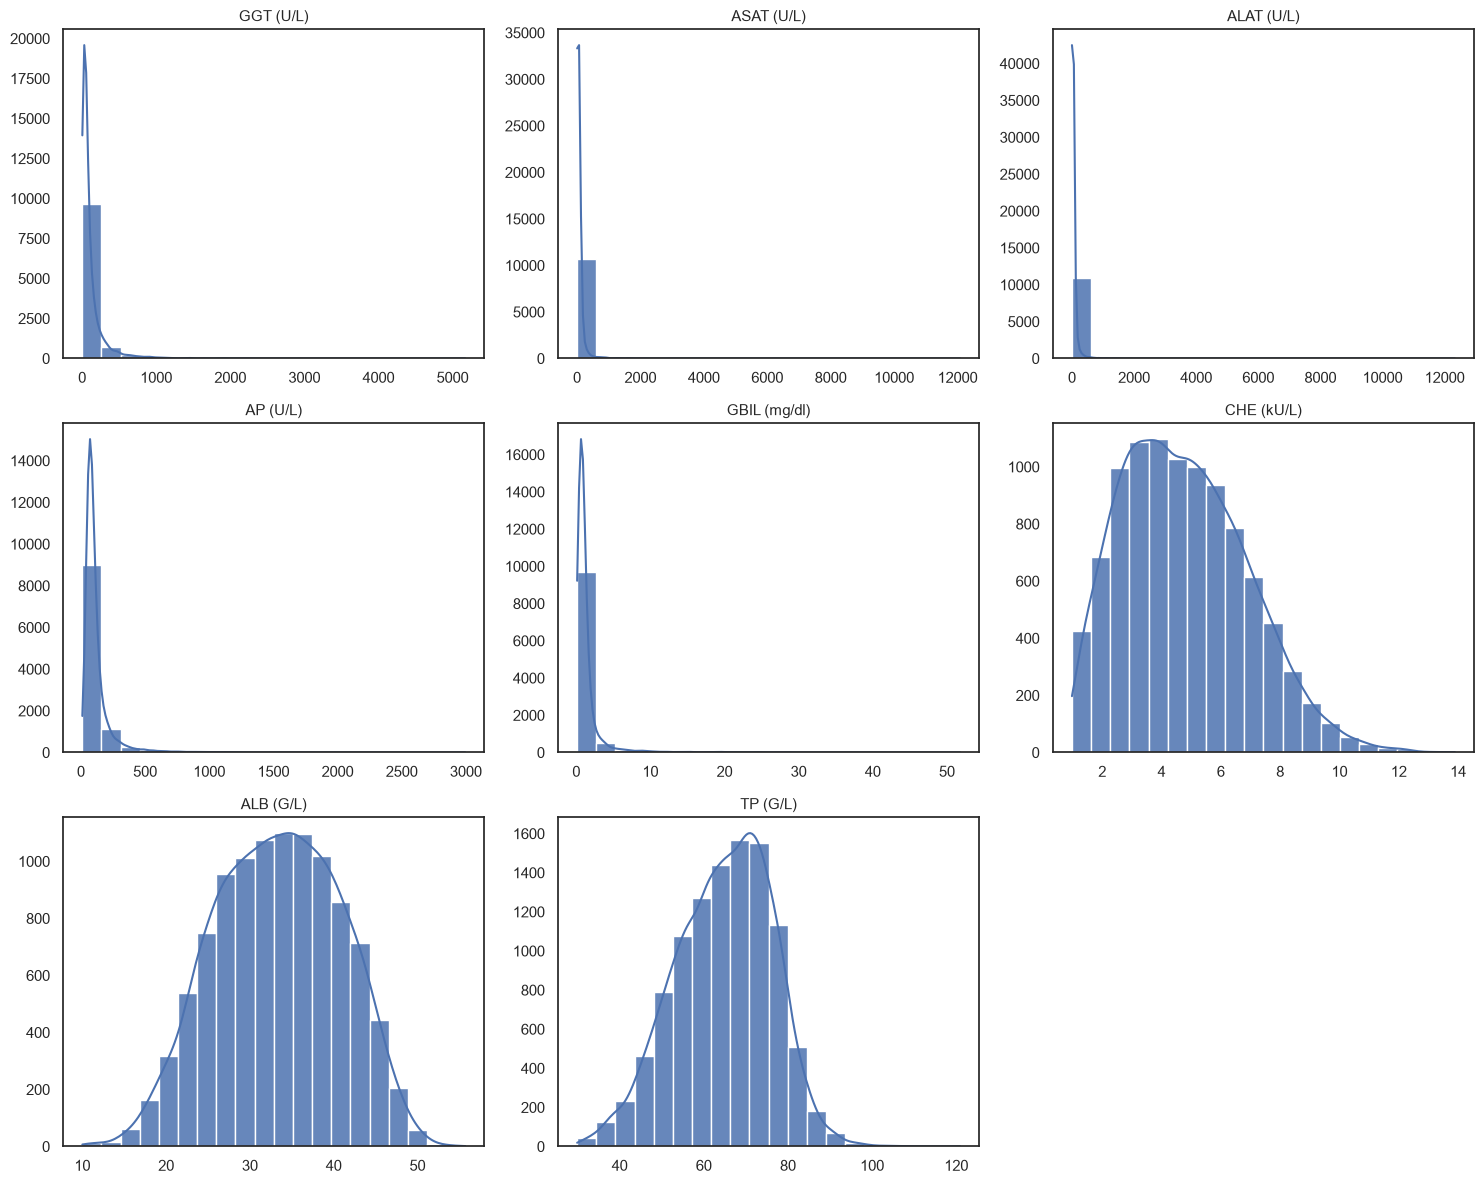

In [87]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1)

colonnes = df_foie.columns
n = len(colonnes)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, colonnes):
    data = df_foie[col].drop_nulls().to_numpy()

    sns.histplot(data, bins=20, kde=True, color="#4C72B0", alpha=0.85, ax=ax)

    ax.set_title(f"{col} ({unites[col]})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()


In [88]:
forme = pl.DataFrame({
    "variable": df_foie.columns,
    "asymetrie": [df_foie[c].skew() for c in df_foie.columns],
    "kurtosis": [df_foie[c].kurtosis() for c in df_foie.columns],
}).sort("kurtosis", descending=True)

forme


variable,asymetrie,kurtosis
str,f64,f64
"""ALAT""",21.871423,656.988425
"""ASAT""",18.566465,437.367269
"""GBIL""",7.982847,83.583913
"""GGT""",6.790592,81.73719
"""AP""",6.874353,78.86525
"""CHE""",0.480551,-0.16562
"""TP""",-0.223275,-0.184227
"""ALB""",-0.087966,-0.592439


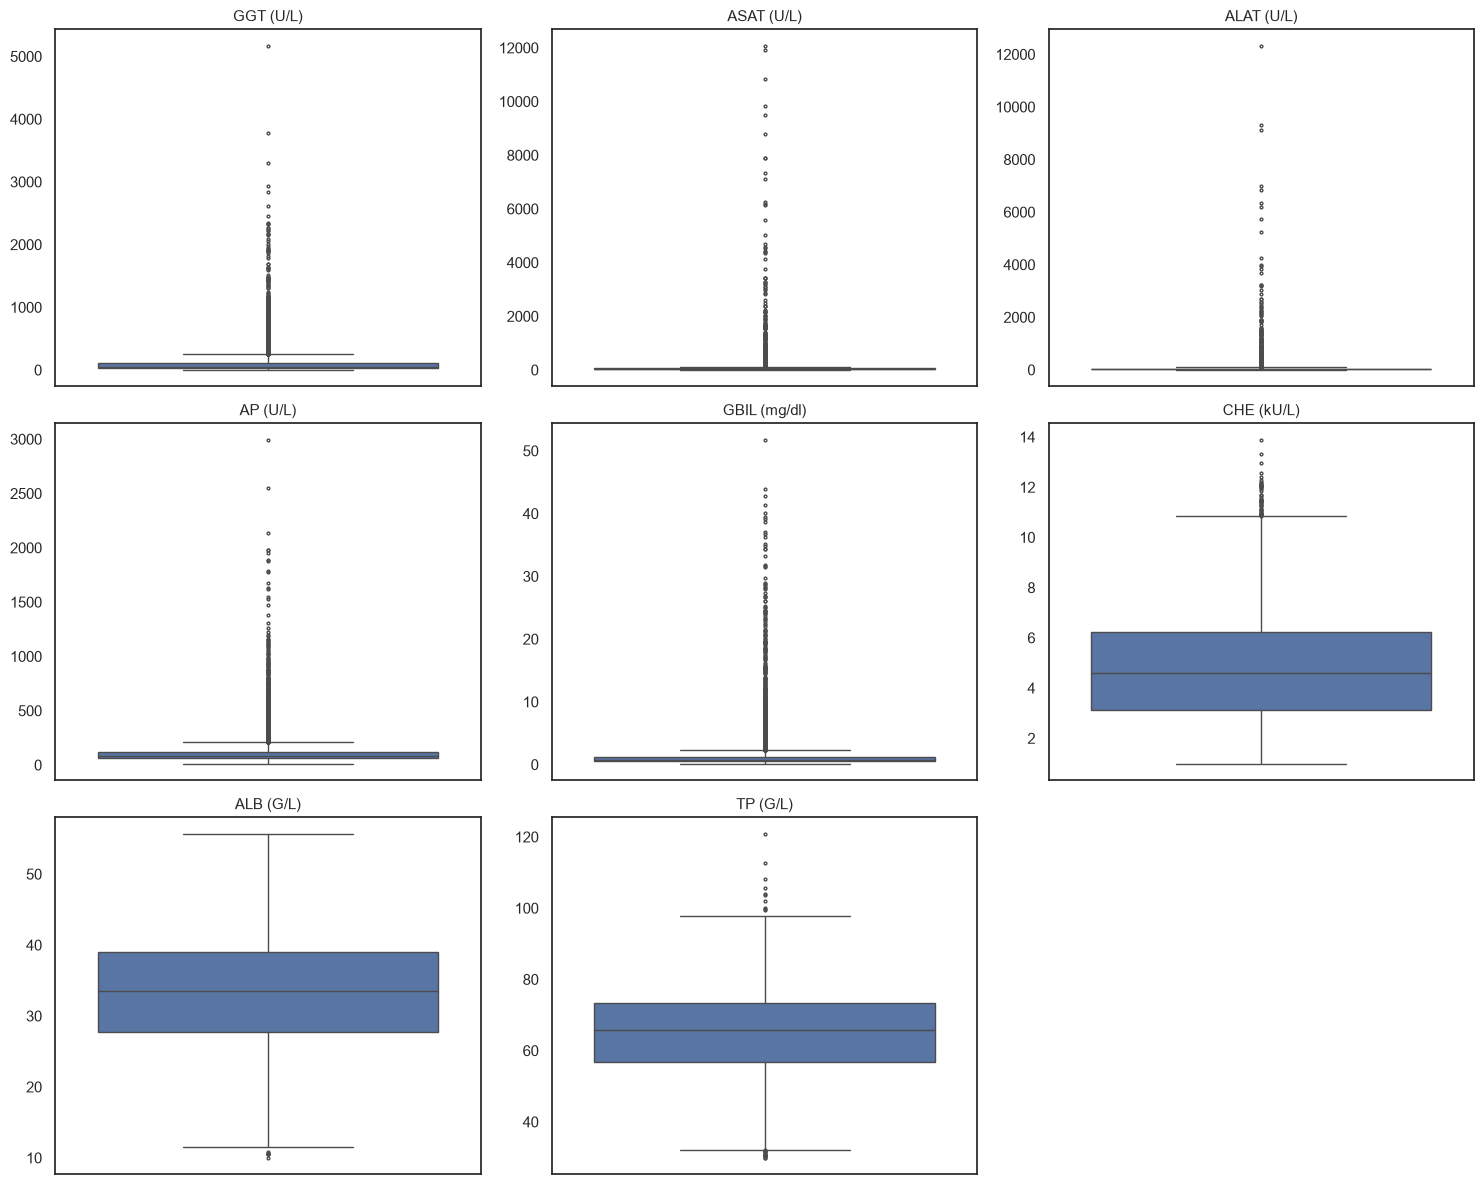

In [89]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1)

colonnes = df_foie.columns
n = len(colonnes)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, colonnes):
    data = df_foie[col].drop_nulls().to_numpy()

    sns.boxplot(y=data, color="#4C72B0", fliersize=2, ax=ax)

    ax.set_title(f"{col} ({unites[col]})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()


#### Lecture des graphiques du bilan hépatique

- **`ALB`, `TP` et `CHE`** dessinent de belles cloches, larges et régulières : ce sont des protéines, dont la concentration varie peu en proportion.
- **Les cinq autres sont illisibles en échelle normale** : `ASAT`, `ALAT`, `GGT`, `AP` et `GBIL` ont des kurtosis de 79 à 657, donc une barre unique et une longue traîne invisible. Le passage au logarithme est obligatoire pour ces variables.
- Les boxplots confirment : des traînées de points extrêmes uniquement au-dessus, jamais en dessous.
- Le groupe mélange donc deux natures très différentes : des protéines bien réparties, et des enzymes à distribution exponentielle.

##### Groupe 9 : muscle et lyse cellulaire

Prescrites quand une souffrance musculaire ou cellulaire est suspectée.
Créatine Kinase (CK) et Lactate Déshydrogénase (LDH) sont des enzymes sériques largement utilisées comme marqueurs de l'atteinte tissulaire, notamment musculaire et hépatique.

In [90]:
muscle = ["CK", "LDH"]
df_muscle = df.select(muscle)
df_muscle.head()


CK,LDH
i64,i64
23,284
36,null
40,696
79,null
75,263


In [91]:
resume_manquants(df_muscle)


variable,n_manquants,pct_manquants
str,u32,f64
"""CK""",1661,14.13
"""LDH""",1358,11.55


In [92]:
df_muscle.describe()


statistic,CK,LDH
str,f64,f64
"""count""",10092.0,10395.0
"""null_count""",1661.0,1358.0
"""mean""",394.709076,330.358826
"""std""",2394.391634,468.038777
"""min""",8.0,39.0
"""25%""",41.0,187.0
"""50%""",81.0,239.0
"""75%""",184.0,332.0
"""max""",98801.0,13906.0


In [93]:
bornes_muscle = {
    "CK": (0, 190), "LDH": (120, 250),
}

part_hors_norme(df_muscle, bornes_muscle)


variable,norme,sous_%,dans_%,au_dessus_%
str,str,f64,f64,f64
"""CK""","""0 - 190""",0.0,75.6,24.4
"""LDH""","""120 - 250""",2.4,51.9,45.7


**Valeurs usuelles et signification des écarts**

| Variable | Valeurs usuelles | En dessous | Au-dessus |
|---|---|---|---|
| `CK` | moins de 190 U/L | — | Destruction musculaire (rhabdomyolyse), effort intense, injection intramusculaire |
| `LDH` | 120–250 U/L | — | Destruction de cellules : hémolyse, manque d'oxygène, cancer |

**Constats sur le muscle et la lyse cellulaire**

- **Près d'un patient sur deux a une `LDH` élevée** (46 %), ce qui traduit une souffrance cellulaire diffuse, sans être spécifique d'un organe.

- **24 % ont une `CK` élevée**, donc une atteinte musculaire.

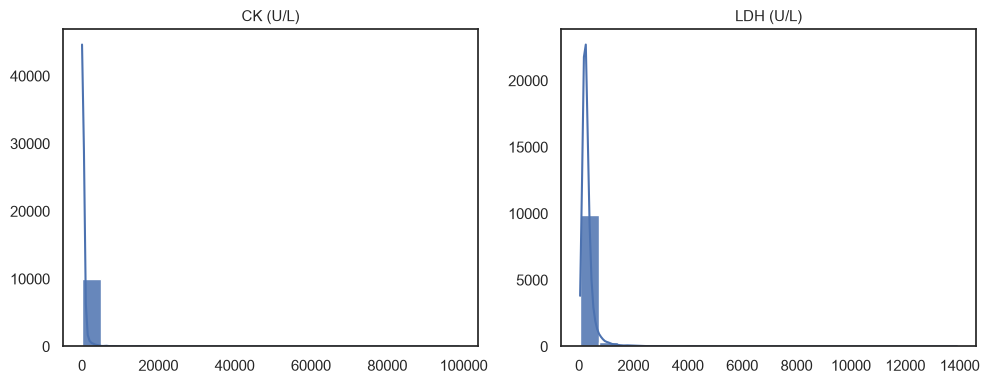

In [94]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1)

colonnes = df_muscle.columns
n = len(colonnes)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, colonnes):
    data = df_muscle[col].drop_nulls().to_numpy()

    sns.histplot(data, bins=20, kde=True, color="#4C72B0", alpha=0.85, ax=ax)

    ax.set_title(f"{col} ({unites[col]})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()


In [95]:
forme = pl.DataFrame({
    "variable": df_muscle.columns,
    "asymetrie": [df_muscle[c].skew() for c in df_muscle.columns],
    "kurtosis": [df_muscle[c].kurtosis() for c in df_muscle.columns],
}).sort("kurtosis", descending=True)

forme


variable,asymetrie,kurtosis
str,f64,f64
"""CK""",23.589548,732.359206
"""LDH""",12.962142,245.928992


- **`CK` est, avec `PAMY`, la variable la plus déséquilibrée du jeu de données** : asymétrie de 23,6 et kurtosis de 732. Médiane à 81 U/L, maximum à 98 801, soit plus de 500 fois la norme.

- **Ces extrêmes sont réels** : une créatine kinase à plusieurs dizaines de milliers correspond à une rhabdomyolyse, destruction massive de muscle. Valeurs conservées.


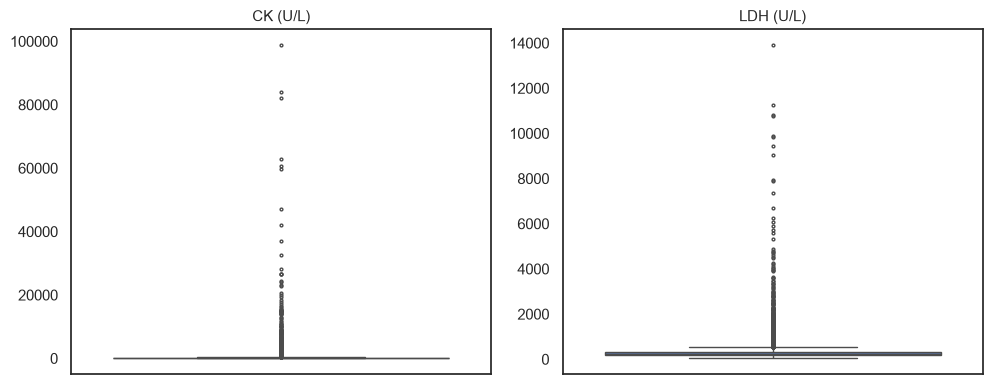

In [96]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1)

colonnes = df_muscle.columns
n = len(colonnes)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, colonnes):
    data = df_muscle[col].drop_nulls().to_numpy()

    sns.boxplot(y=data, color="#4C72B0", fliersize=2, ax=ax)

    ax.set_title(f"{col} ({unites[col]})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()


#### Lecture des graphiques du muscle

- **Les deux histogrammes sont inexploitables en échelle normale** : une seule barre à gauche, et un axe qui s'étire sur cinq ordres de grandeur. C'est le cas le plus extrême du jeu de données.
- **Le logarithme est indispensable** pour ces deux variables, faute de quoi aucun modèle linéaire ne pourra les utiliser.
- Sur les boxplots, la boîte est écrasée à la base et les points extrêmes forment une traînée verticale : la lecture visuelle n'apporte rien de plus que la table `forme`.

##### Groupe 10 : pancréas

Trois analyses, les plus souvent absentes du jeu de données : 25 % de manquants pour `AMY` et `LIP`, et 48 % pour `PAMY`. Ce bilan n'est demandé que devant une douleur abdominale.

- `AMY` : La mesure de l’amylase sérique totale (AMY) utilisé pour le  diagnostic de la pancréatite aiguë. 
- Le test de lipase (ou `LIP`) quantifie la lipase, une enzyme sécrétée exclusivement par le pancréas pour digérer les graisses. 
- L'amylase pancréatique (`PAMY`) est l'isoenzyme spécifique d'origine pancréatique, permettant de distinguer une origine pancréatique d'une origine salivaire en cas d'hyperamylasémie.

In [97]:
pancreas = ["AMY", "LIP", "PAMY"]
df_pancreas = df.select(pancreas)
df_pancreas.head()


AMY,LIP,PAMY
i64,i64,i64
30,10,16
null,null,null
146,89,null
84,50,50
95,25,57


In [98]:
resume_manquants(df_pancreas)


variable,n_manquants,pct_manquants
str,u32,f64
"""PAMY""",5647,48.05
"""AMY""",3102,26.39
"""LIP""",2925,24.89


In [99]:
df_pancreas.describe()


statistic,AMY,LIP,PAMY
str,f64,f64,f64
"""count""",8651.0,8828.0,6106.0
"""null_count""",3102.0,2925.0,5647.0
"""mean""",94.414519,66.864975,42.853914
"""std""",896.536848,667.776574,497.273081
"""min""",8.0,0.0,1.0
"""25%""",33.0,13.0,14.0
"""50%""",50.0,23.0,22.0
"""75%""",76.0,40.0,36.0
"""max""",56146.0,45991.0,38369.0


In [100]:
bornes_pancreas = {
    "AMY": (25, 125), "LIP": (0, 60), "PAMY": (0, 55),
}

part_hors_norme(df_pancreas, bornes_pancreas)


variable,norme,sous_%,dans_%,au_dessus_%
str,str,f64,f64,f64
"""AMY""","""25 - 125""",12.5,77.5,10.0
"""LIP""","""0 - 60""",0.0,85.7,14.3
"""PAMY""","""0 - 55""",0.0,87.3,12.7


**Valeurs usuelles et signification des écarts**

| Variable | Valeurs usuelles | En dessous | Au-dessus |
|---|---|---|---|
| `AMY` | 25–125 U/L | Peu significatif | Pancréatite, mais aussi insuffisance rénale ou atteinte des glandes salivaires |
| `LIP` | moins de 60 U/L | — | Pancréatite aiguë : c'est l'examen de référence |
| `PAMY` | moins de 55 U/L | — | Atteinte pancréatique, plus spécifique que l'amylase totale |

**Constats sur le pancréas**

- **La grande majorité des patients est normale** : 78 % pour `AMY`, 86 % pour `LIP` et 87 % pour `PAMY`. Ce bilan revient le plus souvent négatif, ce qui est logique puisqu'il sert à écarter une piste.

- **Environ un patient testé sur huit dépasse la norme** : 10 % pour `AMY`, 14 % pour `LIP` et 13 % pour `PAMY`.

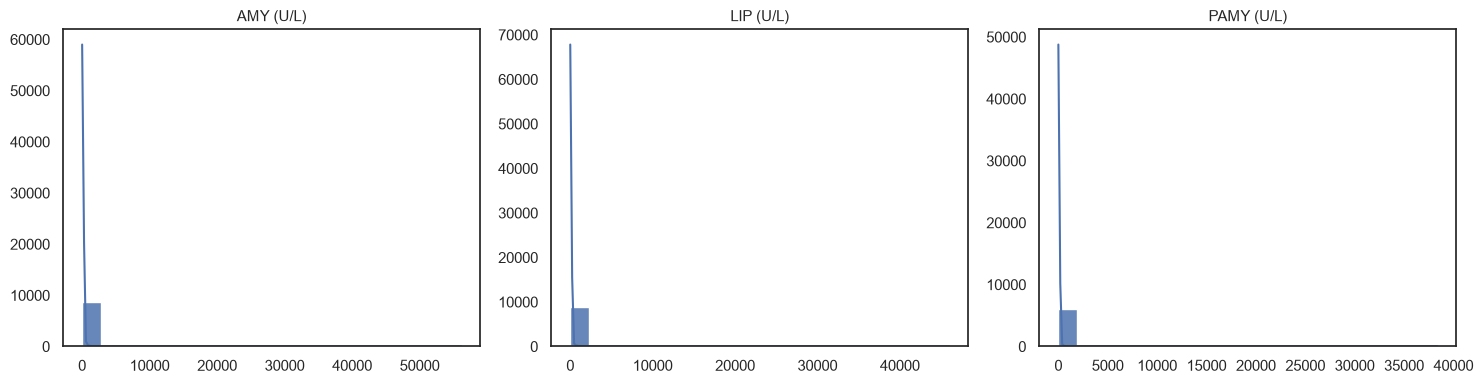

In [101]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1)

colonnes = df_pancreas.columns
n = len(colonnes)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, colonnes):
    data = df_pancreas[col].drop_nulls().to_numpy()

    sns.histplot(data, bins=20, kde=True, color="#4C72B0", alpha=0.85, ax=ax)

    ax.set_title(f"{col} ({unites[col]})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()


In [102]:
forme = pl.DataFrame({
    "variable": df_pancreas.columns,
    "asymetrie": [df_pancreas[c].skew() for c in df_pancreas.columns],
    "kurtosis": [df_pancreas[c].kurtosis() for c in df_pancreas.columns],
}).sort("kurtosis", descending=True)

forme


variable,asymetrie,kurtosis
str,f64,f64
"""PAMY""",75.075294,5778.119486
"""AMY""",52.403411,2898.211763
"""LIP""",46.930023,2799.63398


- **Ce sont les distributions les plus extrêmes du jeu de données** : asymétrie de 52 pour `AMY`, 47 pour `LIP` et 75 pour `PAMY`, avec des kurtosis allant jusqu'à 5 778 et des maxima au-delà de 38 000 U/L. Ce sont des pancréatites aiguës, valeurs réelles.


- **C'est le groupe dont l'indicateur de manquant est le plus prometteur** : qu'un médecin ait demandé un bilan pancréatique signale qu'il suspectait une cause abdominale plutôt qu'une bactériémie.

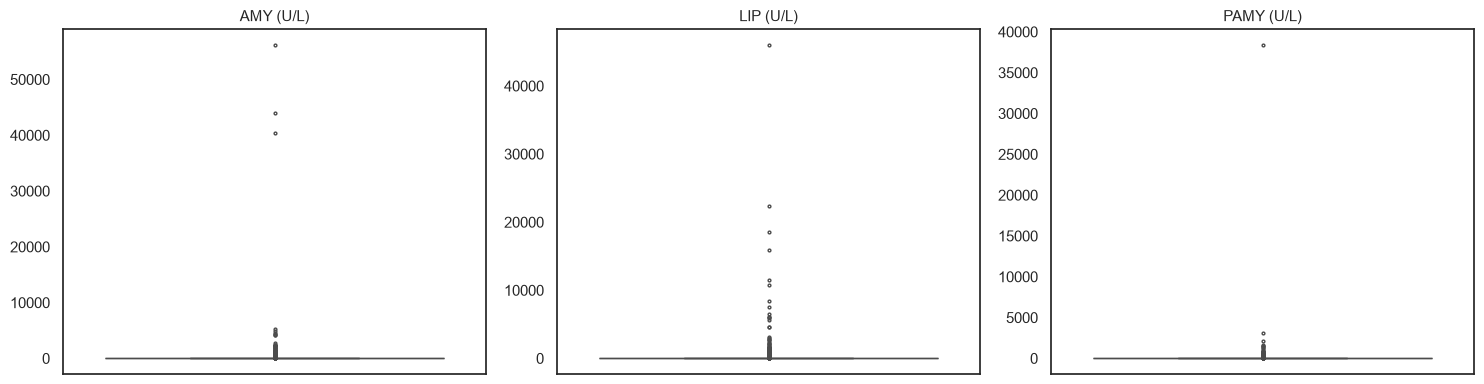

In [103]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1)

colonnes = df_pancreas.columns
n = len(colonnes)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, colonnes):
    data = df_pancreas[col].drop_nulls().to_numpy()

    sns.boxplot(y=data, color="#4C72B0", fliersize=2, ax=ax)

    ax.set_title(f"{col} ({unites[col]})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()


#### Lecture des graphiques du pancréas

- **Les trois histogrammes sont totalement illisibles en échelle normale** : une barre unique collée à zéro, et un axe qui va jusqu'à 56 000.
- **Ces variables demandent impérativement un logarithme**, ou un traitement par seuil du type « supérieur à trois fois la norme ».
- Les boxplots ne montrent qu'une ligne plate et une pluie de points au-dessus : c'est la signature d'une variable où la quasi-totalité des patients est normale et où seuls quelques cas comptent.
- **L'information utile de ce groupe n'est probablement pas la valeur, mais sa présence ou son absence.**

##### Groupe 11 : lipides et glucose

Trois analyses manquantes chez 29 à 35 % des patients. Ce bilan métabolique relève du suivi au long cours, indépendamment de l'épisode infectieux, ce qui explique qu'il se détache complètement des autres sur le dendrogramme.

In [104]:
lipides_glucose = ["TRIG", "CHOL", "GLU"]
df_lipides = df.select(lipides_glucose)
df_lipides.head()

TRIG,CHOL,GLU
i64,i64,i64
105,175,107
null,null,84
null,null,107
152,167,93
85,144,89


In [105]:
resume_manquants(df_lipides)


variable,n_manquants,pct_manquants
str,u32,f64
"""TRIG""",4053,34.48
"""CHOL""",4039,34.37
"""GLU""",3361,28.6


In [106]:
df_lipides.describe()


statistic,TRIG,CHOL,GLU
str,f64,f64,f64
"""count""",7700.0,7714.0,8392.0
"""null_count""",4053.0,4039.0,3361.0
"""mean""",141.676364,150.036038,126.361058
"""std""",122.289067,55.41446,56.273605
"""min""",14.0,25.0,19.0
"""25%""",83.0,113.0,96.0
"""50%""",115.0,144.0,113.0
"""75%""",165.0,182.0,138.0
"""max""",5440.0,1104.0,1403.0


In [107]:
bornes_lipides = {
    "TRIG": (0, 150), "CHOL": (0, 200), "GLU": (70, 110),
}

part_hors_norme(df_lipides, bornes_lipides)


variable,norme,sous_%,dans_%,au_dessus_%
str,str,f64,f64,f64
"""TRIG""","""0 - 150""",0.0,69.5,30.5
"""CHOL""","""0 - 200""",0.0,84.0,16.0
"""GLU""","""70 - 110""",2.0,44.6,53.5


**Valeurs usuelles et signification des écarts**

| Variable | Valeurs usuelles | En dessous | Au-dessus |
|---|---|---|---|
| `GLU` | 70–110 mg/dl à jeun | Hypoglycémie : sepsis grave, insuffisance hépatique | Diabète, ou hyperglycémie de stress très fréquente dans l'infection |
| `CHOL` | moins de 200 mg/dl | Inflammation aiguë, insuffisance hépatique, dénutrition | Risque cardiovasculaire |
| `TRIG` | moins de 150 mg/dl | — | Prélèvement non à jeun, inflammation, diabète |

**Constats sur les lipides et le glucose**

- **Plus d'un patient sur deux est en hyperglycémie** : 54 % dépassent 110 mg/dl. C'est l'hyperglycémie de stress, habituelle dans l'infection aiguë.

- **2 % sont en hypoglycémie**, avec un minimum à 19 mg/dl : rare mais grave.

- **31 % ont des triglycérides élevés**, ce qui accompagne l'inflammation ou un prélèvement non à jeun.

- **Le cholestérol est rarement élevé** : 84 % des patients sont sous 200 mg/dl, avec une médiane à 144. La baisse du cholestérol au cours de l'inflammation aiguë est un phénomène décrit.

- **Ce groupe est le plus indépendant du reste** : sur le dendrogramme, il ne rejoint les autres variables qu'à l'extrémité de l'arbre. Sa présence traduit une prise en charge de fond plutôt qu'une urgence.

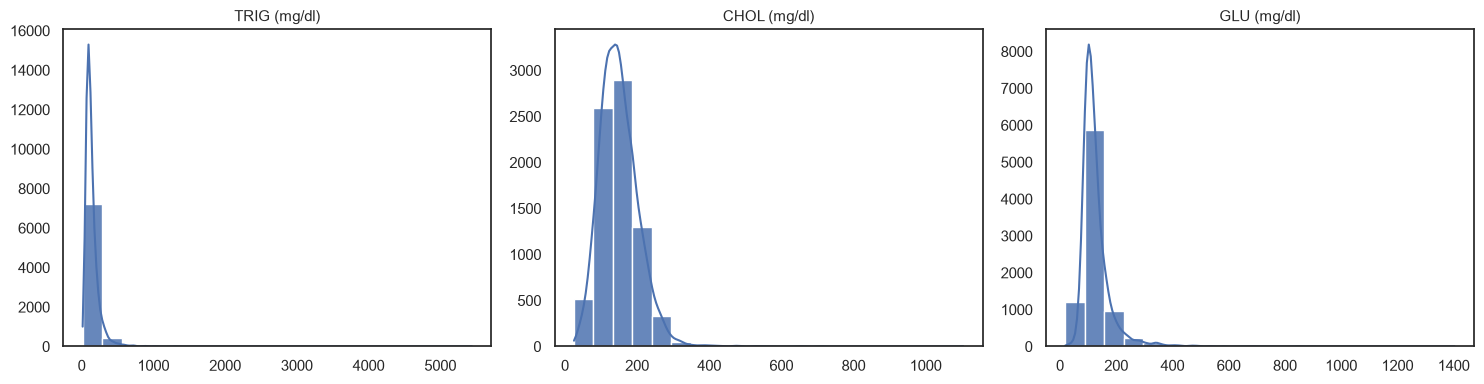

In [108]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1)

colonnes = df_lipides.columns
n = len(colonnes)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, colonnes):
    data = df_lipides[col].drop_nulls().to_numpy()

    sns.histplot(data, bins=20, kde=True, color="#4C72B0", alpha=0.85, ax=ax)

    ax.set_title(f"{col} ({unites[col]})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()


In [109]:
forme = pl.DataFrame({
    "variable": df_lipides.columns,
    "asymetrie": [df_lipides[c].skew() for c in df_lipides.columns],
    "kurtosis": [df_lipides[c].kurtosis() for c in df_lipides.columns],
}).sort("kurtosis", descending=True)

forme


variable,asymetrie,kurtosis
str,f64,f64
"""TRIG""",14.86769,516.087495
"""GLU""",4.968916,56.863664
"""CHOL""",1.756039,16.213591


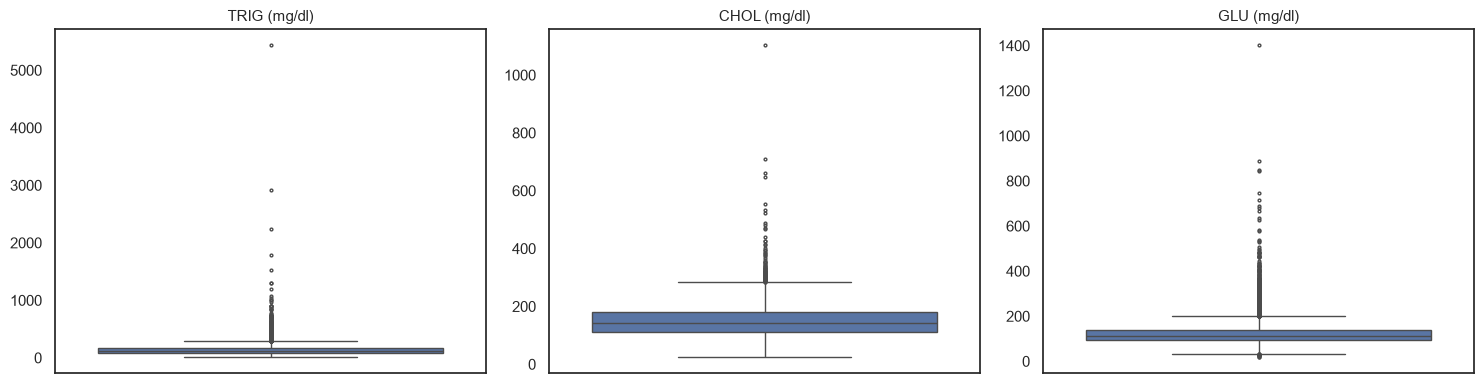

In [110]:
sns.set_style("white")
sns.set_context("notebook", font_scale=1)

colonnes = df_lipides.columns
n = len(colonnes)
rows = math.ceil(n / 3)

fig, axes = plt.subplots(rows, 3, figsize=(15, 4 * rows))
axes = axes.flatten()

for ax, col in zip(axes, colonnes):
    data = df_lipides[col].drop_nulls().to_numpy()

    sns.boxplot(y=data, color="#4C72B0", fliersize=2, ax=ax)

    ax.set_title(f"{col} ({unites[col]})", fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("")

for ax in axes[n:]:
    ax.remove()

plt.tight_layout()
plt.show()


#### Lecture des graphiques des lipides et du glucose

- **`CHOL`** est la variable la mieux répartie du groupe (asymétrie 1,76) : une cloche décalée à droite, lisible telle quelle.
- **`GLU` et `TRIG`** ont des queues droites marquées (asymétrie 5,0 et 14,9) : le logarithme est nécessaire.
- Les boxplots montrent des points extrêmes uniquement au-dessus, sauf pour `GLU` qui en a aussi en dessous : ce sont les hypoglycémies, cliniquement importantes.
- **Aucune valeur impossible** dans ce groupe.

##### Comparaison de chaque variable avec la cible

Une variable est utile si elle sépare les patients avec bactériémie des autres. On le mesure par l'**AUC univariée**.

| AUC | Lecture |
|---|---|
| 0,50 | hasard |
| 0,60 | faible |
| 0,70 | correct en biologie |

`max(auc, 1 - auc)` traite de la même façon les variables qui montent et celles qui baissent chez les malades. La colonne `sens` donne la direction.

Avec 11 753 patients, presque tous les tests seraient significatifs : on regarde l'AUC, pas la p-value.

In [111]:
from sklearn.metrics import roc_auc_score

# Le compte de defaillances d'organe est evalue en meme temps que les variables brutes
df_cible = df.with_columns(
    nb_anomalies=pl.sum_horizontal([
        (pl.col("PLT") < 150).cast(pl.Int8),
        (pl.col("CREA") > 1.3).cast(pl.Int8),
        (pl.col("GBIL") > 1.2).cast(pl.Int8),
        (pl.col("NT") < 70).cast(pl.Int8),
        (pl.col("ALB") < 35).cast(pl.Int8),
        (pl.col("LYM") < 1).cast(pl.Int8),
    ])
)

lignes = []
for col in [c for c in df_cible.columns if c != "BloodCulture"]:
    sub = df_cible.select(col, "BloodCulture").drop_nulls()
    a = roc_auc_score(sub["BloodCulture"], sub[col])
    lignes.append({
        "variable": col,
        "auc": round(max(a, 1 - a), 3),
        "sens": "+" if a > 0.5 else "-",
        "n": sub.height,
    })

classement = pl.DataFrame(lignes).sort("auc", descending=True)

classement


variable,auc,sens,n
str,f64,str,i64
"""NEUR""",0.696,"""+""",11161
"""LYM""",0.686,"""-""",11541
"""LYMR""",0.673,"""-""",11161
"""nb_anomalies""",0.655,"""+""",11753
"""MONOR""",0.634,"""-""",11161
"""BUN""",0.63,"""+""",11617
"""EOSR""",0.629,"""-""",11161
"""EOS""",0.627,"""-""",11639
"""GBIL""",0.626,"""+""",10602


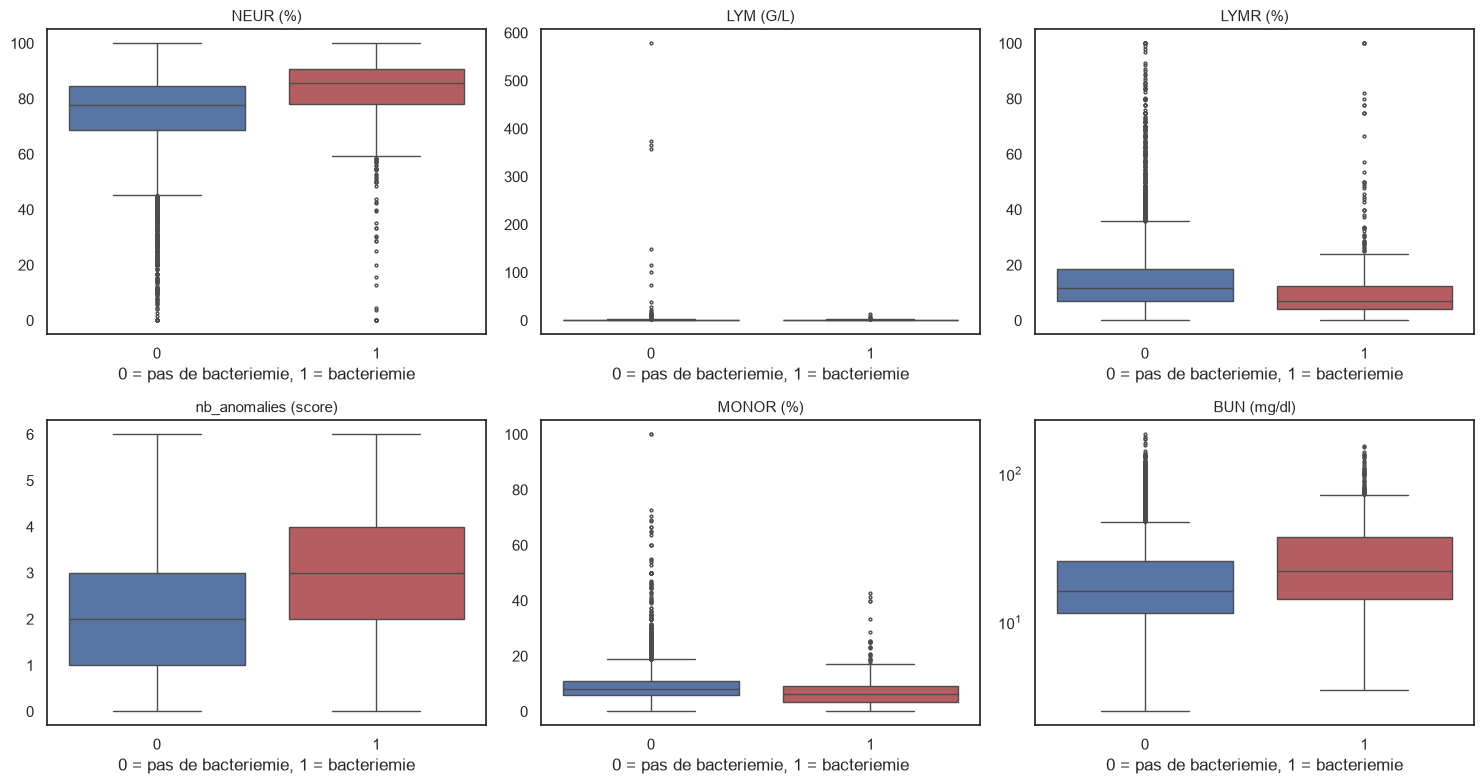

In [115]:
# Boxplots par classe pour les six meilleures variables
meilleures = classement.head(6)["variable"].to_list()

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, meilleures):
    sub = df_cible.select(col, "BloodCulture").drop_nulls()
    sns.boxplot(x=sub["BloodCulture"], y=sub[col], hue=sub["BloodCulture"],
                palette=["#4C72B0", "#C44E52"], legend=False, fliersize=2, ax=ax)

    # Echelle log quand la variable est tres asymetrique, sinon la boite est ecrasee
    if sub[col].min() > 0 and sub[col].skew() > 2:
        ax.set_yscale("log")

    ax.set_title(f"{col} ({unites.get(col, 'score')})", fontsize=11)
    ax.set_xlabel("0 = pas de bacteriemie, 1 = bacteriemie")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()


**Résultats**

| Variable | Notre AUC | AUC publiée |
|---|---|---|
| `NEUR` | **0,696** | 0,696 |
| `LYM` | 0,686 | 0,683 |
| `LYMR` | 0,673 | 0,674 |
| `nb_anomalies` | 0,655 | variable construite |
| `MONOR` | 0,634 | 0,645 |
| `BUN` | 0,630 | 0,633 |
| `EOSR` | 0,629 | 0,626 |
| `GBIL` | 0,626 | 0,621 |
| `AGE` | 0,613 | 0,611 |
| `CREA` | 0,612 | 0,611 |
| `CRP` | 0,600 | 0,596 |

Nos valeurs collent à celles de l'article d'origine, à moins de 0,015 près : la colonne `From.paper` du cahier contient ses AUC (Ratzinger F. et al., PLoS ONE 9(9), e106765, 2014).

- **Les trois meilleures variables sont des globules blancs.**
- **`WBC` seul ne vaut rien** (0,512) alors que `NEUR` atteint 0,696 : c'est la composition qui compte, pas la quantité.
- **Le compte de défaillances d'organe se classe 4e** (0,655) avec six seuils seulement, mais il ne dépasse pas `NEUR`. Le gradient de 3 % à 27 % vu plus haut est flatteur, car le dernier groupe ne compte que 151 patients : à groupes de taille égale, les quintiles de `NEUR` vont de 3,3 % à 17,9 % et le compte d'anomalies de 3,0 % à 15,4 %.
- **La CRP déçoit** (0,600), car 93 % des patients l'ont déjà élevée.
- **Aucune variable ne dépasse 0,70** : il faudra les combiner.

À refaire sur le jeu d'entraînement seul, sinon le choix des variables tiendrait compte du jeu de test.

##### Test de Mann-Whitney

Le test compare les deux groupes sans supposer une distribution normale : il travaille sur les rangs, pas sur les valeurs. C'est ce qu'il faut ici, nos variables étant très asymétriques, là où un test de Student serait faussé par les valeurs extrêmes.

La colonne `u_sur_n1n2` est la statistique du test rapportée au nombre de paires possibles.

In [113]:
from scipy.stats import mannwhitneyu

lignes = []
for col in [c for c in df.columns if c != "BloodCulture"]:
    sub = df.select(col, "BloodCulture").drop_nulls()
    malades = sub.filter(pl.col("BloodCulture") == 1)[col].to_numpy()
    sains = sub.filter(pl.col("BloodCulture") == 0)[col].to_numpy()

    u, pvalue = mannwhitneyu(malades, sains, alternative="two-sided")

    lignes.append({
        "variable": col,
        "p_value": pvalue,
        "u_sur_n1n2": round(u / (len(malades) * len(sains)), 3),
    })

test = pl.DataFrame(lignes).with_columns(significatif=pl.col("p_value") < 0.05).sort("p_value")

test


variable,p_value,u_sur_n1n2,significatif
str,f64,f64,bool
"""NEUR""",3.1280e-83,0.696,true
"""LYM""",7.6739e-79,0.314,true
"""LYMR""",3.9252e-65,0.327,true
"""EOS""",4.7092e-43,0.373,true
"""EOSR""",1.4907e-41,0.371,true
"""BUN""",4.1242e-40,0.63,true
"""MONOR""",1.8486e-39,0.366,true
"""GBIL""",1.3658e-33,0.626,true
"""SODIUM""",3.1403e-32,0.382,true


**Résultats**

- **44 variables sur 51 sont significatives** (p < 0,05). Les 7 autres sont `TRIG`, `MPV`, `PDW`, `WBC`, `APTT`, `SEX` et `POTASS`, exactement celles dont l'AUC est voisine de 0,50.

- **`u_sur_n1n2` reproduit exactement l'AUC calculée plus haut.** Ce n'est pas une coïncidence : l'AUC est par définition la statistique de Mann-Whitney divisée par le nombre de paires.

- **La p-value est ici peu utile.** `MCHC` ressort significative (p = 0,029) pour une AUC de 0,521, et `MCV` aussi (p = 0,017) pour 0,523 : des écarts réels mais sans intérêt clinique, détectés seulement grâce à la taille de l'échantillon.

**À retenir** : le test confirme, l'AUC classe. C'est l'AUC qui sert à choisir les variables.

##### Corrélations entre les meilleures variables

Une variable très corrélée à une autre déjà retenue n'apporte rien de plus. On ne regarde donc que les dix premières du classement.

Spearman plutôt que Pearson : il travaille sur les rangs, donc un `CK` à 98 801 ne domine pas le calcul.

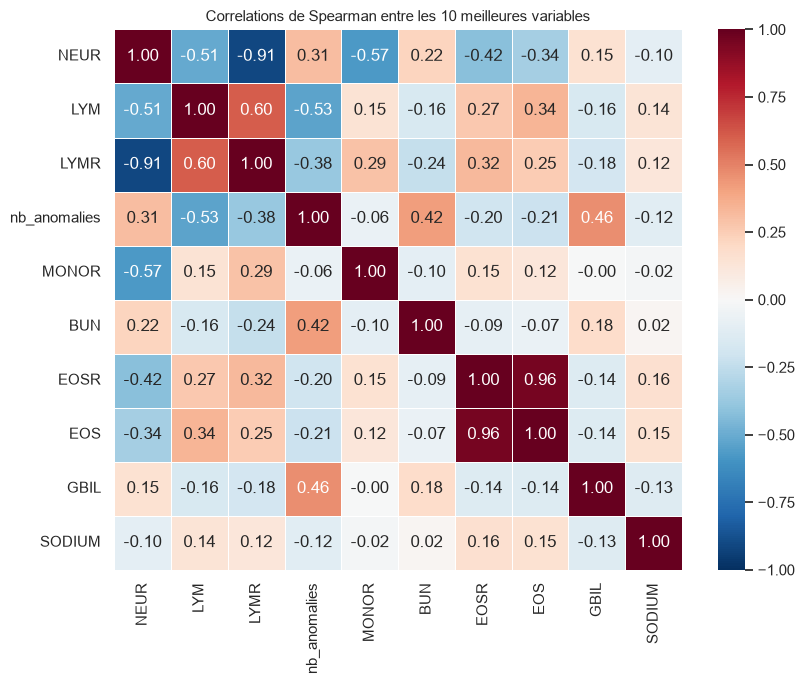

In [114]:
meilleures = classement.head(10)["variable"].to_list()

# Spearman = Pearson applique aux rangs
correlations = (
    df_cible.select(meilleures).drop_nulls()
    .select([pl.col(c).rank().alias(c) for c in meilleures])
    .corr()
)

plt.figure(figsize=(8.5, 7))
sns.heatmap(
    correlations.to_numpy(), annot=True, fmt=".2f", cmap="RdBu_r", center=0, vmin=-1, vmax=1,
    xticklabels=meilleures, yticklabels=meilleures, linewidths=0.5,
)
plt.title("Correlations de Spearman entre les 10 meilleures variables", fontsize=11)
plt.tight_layout()
plt.show()


**Résultats**

Deux paires portent la même information :

| Paire | Corrélation |
|---|---|
| `NEUR` et `LYMR` | **−0,91** |
| `EOS` et `EOSR` | **0,96** |

C'est attendu : quand les neutrophiles occupent la place, les lymphocytes la perdent, et `EOSR` n'est que `EOS` rapporté aux globules blancs.

**Le compte d'anomalies est bien complémentaire** : il n'est corrélé qu'à 0,31 avec `NEUR`, −0,53 avec `LYM` et 0,46 avec `GBIL`. Il apporte donc une information différente de celle du profil leucocytaire, ce qui justifie de le garder.

Le reste est faiblement corrélé : `LYM` avec `LYMR` à 0,60, `NEUR` avec `MONOR` à −0,57, et moins de 0,50 partout ailleurs.

**Ce qu'on en fait** : pour un modèle linéaire, garder `NEUR` et écarter `LYMR`, garder `EOS` et écarter `EOSR`. Pour les modèles à base d'arbres, tout garder.